# Emergency Department Triage: Acuity Prediction Model
## Predicting Patient Acuity Level (ESI 1-5) from Clinical Features

**Objective**: Build a machine learning model to predict patient acuity level (ESI 1-5) using clinical data and chief complaints.

**Model Architecture**:
- **LightGBM Classifier** for multi-class ordinal classification
- **ClinicalBERT embeddings** for semantic understanding of clinical text (chief complaints)
- **Chi-Square TF-IDF feature selection** for extracting discriminative clinical keywords
- **Advanced feature engineering** (BP ratios, cyclic encoding, comorbidity interactions)

**Key Features**:
- ClinicalBert for clinical text embeddings from chief_complaint_raw
- Chi2TextFeatureSelector for TF-IDF feature selection per class
- Advanced feature engineering (cyclic encoding, BP ratios, comorbidity interactions)
- Weighted Kappa metrics for ordinal classification (clinically meaningful)
- SHAP explainability for clinical trust and interpretability

**Evaluation Metrics**:
- Accuracy, Cohen's Kappa, Confusion Matrix
- Undertriage/Overtriage analysis for clinical safety
- Per-class performance (Precision, Recall, F1-Score)

**Date**: 2026-04-04


In [11]:
# ============================================================================
# SECTION 1: IMPORTS - Core Libraries for Acuity Prediction Pipeline
# ============================================================================
# This notebook implements a single-stage acuity prediction pipeline:
# INPUT: Clinical data (vitals, demographics, chief complaints)
# OUTPUT: Predicted acuity level (ESI 1-5)
#
# Libraries imported:
# - Data manipulation: pandas, numpy
# - ML & preprocessing: scikit-learn pipelines, transformers, model selection
# - Gradient boosting: LightGBM (primary model for acuity classification)
# - NLP: HuggingFace Transformers (ClinicalBERT for clinical text embeddings)
# - Visualization: matplotlib, seaborn
# - Text processing: TfidfVectorizer, chi2 feature selection
# - Model evaluation: confusion matrix, f1-score, cohen_kappa_score (ordinal metrics)

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn: preprocessing, pipelines, and model selection
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, 
    cohen_kappa_score, 
    confusion_matrix, 
    classification_report,
    f1_score,
    roc_auc_score
)

# Ensemble and gradient boosting models
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from lightgbm import LGBMClassifier

# Text processing for chief complaint narratives
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.base import BaseEstimator, TransformerMixin

# Transformers library: state-of-the-art NLP models for clinical text
try:
    import torch
    from transformers import AutoTokenizer, AutoModel
    TRANSFORMERS_AVAILABLE = True
    DEVICE = 'cpu'
    if torch.cuda.is_available():
        DEVICE = 'cuda'
    if torch.xpu.is_available():
        DEVICE = 'xpu'
except ImportError:
    print("⚠️  HuggingFace transformers not installed. Will use TF-IDF fallback.")
    TRANSFORMERS_AVAILABLE = False
    DEVICE = 'cpu'

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seeds for reproducibility across runs
np.random.seed(42)

print("✓ All imports successful!")
print(f"✓ Transformers available: {TRANSFORMERS_AVAILABLE}")
print(f"✓ Device for embeddings: {DEVICE}")

✓ All imports successful!
✓ Transformers available: True
✓ Device for embeddings: xpu


# SECTION 2: DATA LOADING AND EXPLORATION

## Step 1: Load and Merge Raw CSV Files
We load clinical data from four CSV files and merge them on `patient_id`:
- `train.csv`: Contains triage_acuity (target ESI 1-5), disposition, ed_los_hours
- `test.csv`: Test set (no labels)
- `chief_complaints.csv`: Raw text chief complaints + system category
- `patient_history.csv`: Medical history and comorbidities

**Data Preprocessing**:
- Merge patient information (complaints + medical history)
- **Drop 'chief_complaint_system'** to prevent information leakage (categorical features derived from text)
- Keep only raw text ('chief_complaint_raw') for feature extraction
- Ensure all unique patients are captured


In [12]:

# ============================================================================
# SECTION 2: DATA LOADING AND MERGING
# ============================================================================
# Goal: Load clinical data from multiple CSV files and merge on patient_id
# Target: triage_acuity (ESI 1-5 rating)
# Features: Vitals (HR, BP, RR, SpO2), demographics, medical history, text

print("=" * 80)
print("LOADING DATA FILES")
print("=" * 80)

# Load train and test sets
train_df = pd.read_csv("dataset/train.csv")
test_df = pd.read_csv("dataset/test.csv")

# Load patient information (chief complaints and medical history)
chief_complaints_df = pd.read_csv("dataset/chief_complaints.csv")
patient_history_df = pd.read_csv("dataset/patient_history.csv")

print(f"\n📊 INITIAL DATASET SHAPES:")
print(f"   train.csv:                {train_df.shape}")
print(f"   test.csv:                 {test_df.shape}")
print(f"   chief_complaints.csv:     {chief_complaints_df.shape}")
print(f"   patient_history.csv:      {patient_history_df.shape}")

# ============================================================================
# MERGE: Combine chief_complaints + patient_history on patient_id
# ============================================================================
patient_info_df = chief_complaints_df.merge(
    patient_history_df,
    on="patient_id",
    how="outer"
)

print(f"\n📋 MERGED PATIENT INFO: {patient_info_df.shape}")

# ============================================================================
# DROP chief_complaint_system — CLINICAL & METHODOLOGICAL JUSTIFICATION
# ============================================================================
# This column is a body-system categorisation (e.g. "cardiovascular", "respiratory")
# algorithmically derived from the free-text chief_complaint_raw field.
# We exclude it for two principled reasons:
#
#   1. NOT AVAILABLE AT THE POINT OF TRIAGE in real ED workflows.
#      A triage nurse records the free-text complaint; a system taxonomy is a
#      post-hoc administrative label that would not exist at prediction time.
#      Using it would make the model non-deployable in a real clinical setting.
#
#   2. REDUNDANT given our NLP pipeline.
#      Our ClinicalBERT encoder + Chi-Square TF-IDF selector learn richer,
#      domain-adapted representations directly from raw text that subsume any
#      fixed categorical taxonomy. Keeping chief_complaint_system would let the
#      model shortcut the NLP learning via a human-curated abstraction, reducing
#      the clinical credibility of the approach.

if 'chief_complaint_system' in train_df.columns:
    train_df.drop(columns=['chief_complaint_system'], inplace=True)
if 'chief_complaint_system' in test_df.columns:
    test_df.drop(columns=['chief_complaint_system'], inplace=True)
if 'chief_complaint_system' in patient_info_df.columns:
    patient_info_df.drop(columns=['chief_complaint_system'], inplace=True)

print("✓ Dropped 'chief_complaint_system' (not available at triage; NLP pipeline supersedes it)")

# ============================================================================
# MERGE: Add patient info to train and test sets
# ============================================================================
train_full_df = train_df.merge(patient_info_df, on="patient_id", how="left")
test_full_df  = test_df.merge(patient_info_df,  on="patient_id", how="left")

print(f"\n✓ MERGED TRAIN+INFO: {train_full_df.shape}")
print(f"✓ MERGED TEST+INFO:  {test_full_df.shape}")
print(f"\n📌 SAMPLE ROW (first row of train_full_df):")
print(train_full_df.iloc[0][:10])


LOADING DATA FILES

📊 INITIAL DATASET SHAPES:
   train.csv:                (80000, 40)
   test.csv:                 (20000, 37)
   chief_complaints.csv:     (100000, 3)
   patient_history.csv:      (100000, 26)

📋 MERGED PATIENT INFO: (100000, 28)
✓ Dropped 'chief_complaint_system' (not available at triage; NLP pipeline supersedes it)

✓ MERGED TRAIN+INFO: (80000, 65)
✓ MERGED TEST+INFO:  (20000, 62)

📌 SAMPLE ROW (first row of train_full_df):
patient_id         TG-UXRGA9UCO
site_id             SITE-TMP-01
triage_nurse_id      NURSE-0033
arrival_mode            walk-in
arrival_hour                  6
arrival_day              Monday
arrival_month                 5
arrival_season           spring
shift                   morning
age                          43
Name: 0, dtype: object


In [13]:

# ============================================================================
# PREPARE DATA FOR ACUITY PREDICTION
# ============================================================================

# Numeric mapping for disposition (reference only, not used as feature)
DISPOSITION_DICT = {
    'discharged': 0, 'admitted': 1, 'transferred': 2,
    'observation': 3, 'lwbs': 4, 'lama': 5, 'deceased': 6
}
NUM_TO_DISPOSITION = {v: k for k, v in DISPOSITION_DICT.items()}

train_full_df['disposition'] = train_full_df['disposition'].map(DISPOSITION_DICT)

# ============================================================================
# PAIN SCORE: -1 IS A CLINICAL SENTINEL VALUE (not a real pain rating)
# ============================================================================
# In many ED systems, pain_score = -1 means "pain was not assessed":
#   - Patient may be unable to self-report (altered consciousness, very young child)
#   - Visit may be non-painful in nature (e.g., psychiatric, social admission)
#   - Rapid-track patients sometimes bypass formal pain scoring
# We create a binary flag capturing this clinical signal BEFORE recoding to NaN.

def apply_pain_sentinel_fix(df):
    """Recode pain_score -1 → NaN and create pain_not_recorded indicator."""
    if 'pain_score' in df.columns:
        df['pain_not_recorded'] = (df['pain_score'] == -1).astype(int)
        df.loc[df['pain_score'] == -1, 'pain_score'] = np.nan
    return df

train_full_df = apply_pain_sentinel_fix(train_full_df)
test_full_df  = apply_pain_sentinel_fix(test_full_df)

print(f"✓ pain_not_recorded flag created")
print(f"   Train: {train_full_df['pain_not_recorded'].sum():,} patients with unrecorded pain")
print(f"   Test:  {test_full_df['pain_not_recorded'].sum():,} patients with unrecorded pain")

# ============================================================================
# TARGET AND FEATURES FOR ACUITY PREDICTION
# ============================================================================
target_acuity = train_full_df['triage_acuity']   # ESI 1-5

# Drop non-feature columns: identifiers, downstream outcomes
features_df = train_full_df.drop(
    columns=['patient_id', 'triage_acuity', 'disposition', 'ed_los_hours']
)

print(f"\n✓ TARGET: {target_acuity.shape[0]:,} samples | Classes: {sorted(target_acuity.unique())}")
print(f"  Distribution:\n{target_acuity.value_counts().sort_index()}")
print(f"\n✓ FEATURES: {features_df.shape}")
print(f"  Columns (first 15): {features_df.columns.tolist()[:15]}")


✓ pain_not_recorded flag created
   Train: 11,156 patients with unrecorded pain
   Test:  2,913 patients with unrecorded pain

✓ TARGET: 80,000 samples | Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Distribution:
triage_acuity
1     3222
2    13439
3    28921
4    23020
5    11398
Name: count, dtype: int64

✓ FEATURES: (80000, 62)
  Columns (first 15): ['site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_hour', 'arrival_day', 'arrival_month', 'arrival_season', 'shift', 'age', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location']


In [14]:

# ============================================================================
# STEP 2.5: CLINICAL MISSINGNESS INDICATORS + GROUP-MEDIAN IMPUTATION
# ============================================================================
# In emergency medicine, missing vital signs are NOT random (MNAR — Missing Not At Random).
# A patient whose blood pressure was never recorded differs clinically from one whose
# BP is 120/80: the former may be in extremis, was rapidly stabilised, or was assessed
# by a different care pathway. Capturing this missingness signal explicitly improves
# model calibration and clinical interpretability.
#
# IMPUTATION STRATEGY: group-median by (age_group × shift)
# Normal vital sign ranges differ by age (paediatric vs. geriatric) and by shift
# (night-shift patients in many EDs have a different acuity mix). Group-median
# imputation is more clinically defensible than a global constant or sentinel -1.
# We store the lookup table so the same transformation can be applied to test data.

print("=" * 80)
print("CLINICAL MISSINGNESS FLAGS + GROUP-MEDIAN IMPUTATION")
print("=" * 80)

# --- MISSINGNESS INDICATOR FLAGS ---
# Created BEFORE any imputation so they capture genuine missingness.
missingness_cols = [
    'systolic_bp', 'diastolic_bp', 'mean_arterial_pressure',
    'pulse_pressure', 'shock_index', 'respiratory_rate'
]

print("\n📌 Missingness indicator flags:")
for col in missingness_cols:
    if col in features_df.columns:
        n_missing = features_df[col].isnull().sum()
        features_df[f'{col}_missing'] = features_df[col].isnull().astype(int)
        print(f"   ✓ {col}_missing  (n_missing={n_missing:,})")

# --- GROUP-MEDIAN IMPUTATION ---
# Impute using per-(age_group, shift) median; fall back to global median.
# Medians are computed on the training feature set and stored for test inference.
impute_cols = [
    'systolic_bp', 'diastolic_bp', 'mean_arterial_pressure',
    'pulse_pressure', 'shock_index', 'respiratory_rate',
    'temperature_c', 'pain_score'
]

# Store for reuse on test_full_df
group_median_table = {}
global_median_table = {}

print("\n📐 Group-median imputation (age_group × shift):")
for col in impute_cols:
    if col not in features_df.columns:
        continue
    n_before = features_df[col].isnull().sum()
    # Vectorised: transform computes per-group median aligned to original index
    group_fill = features_df.groupby(['age_group', 'shift'])[col].transform('median')
    global_med = features_df[col].median()

    # Store for test-set use
    group_median_table[col] = features_df.groupby(['age_group', 'shift'])[col].median().to_dict()
    global_median_table[col] = global_med

    features_df[col] = features_df[col].fillna(group_fill).fillna(global_med)
    n_after = features_df[col].isnull().sum()
    print(f"   ✓ {col}: {n_before:,} NaN → {n_after:,} remaining (global fallback: {global_med:.1f})")

print(f"\n✓ Imputation complete. Lookup tables stored in 'group_median_table' / 'global_median_table'.")
print(f"   features_df shape after preprocessing: {features_df.shape}")


def preprocess_test_df(df):
    """Apply the same missingness flags and group-median imputation to any new dataset."""
    df = df.copy()
    # Missingness flags
    for col in missingness_cols:
        if col in df.columns:
            df[f'{col}_missing'] = df[col].isnull().astype(int)
    # Group-median imputation using training-set medians
    for col in impute_cols:
        if col not in df.columns:
            continue
        mask = df[col].isnull()
        if not mask.any():
            continue
        keys = list(zip(df.loc[mask, 'age_group'].astype(str),
                        df.loc[mask, 'shift'].astype(str)))
        fill_vals = [group_median_table.get(col, {}).get(k, global_median_table.get(col, 0))
                     for k in keys]
        df.loc[mask, col] = fill_vals
    return df

print("\n✓ preprocess_test_df() helper defined (reuses training-set medians).")


CLINICAL MISSINGNESS FLAGS + GROUP-MEDIAN IMPUTATION

📌 Missingness indicator flags:
   ✓ systolic_bp_missing  (n_missing=4,146)
   ✓ diastolic_bp_missing  (n_missing=4,146)
   ✓ mean_arterial_pressure_missing  (n_missing=4,146)
   ✓ pulse_pressure_missing  (n_missing=4,146)
   ✓ shock_index_missing  (n_missing=4,146)
   ✓ respiratory_rate_missing  (n_missing=3,067)

📐 Group-median imputation (age_group × shift):
   ✓ systolic_bp: 4,146 NaN → 0 remaining (global fallback: 123.1)
   ✓ diastolic_bp: 4,146 NaN → 0 remaining (global fallback: 75.3)
   ✓ mean_arterial_pressure: 4,146 NaN → 0 remaining (global fallback: 91.9)
   ✓ pulse_pressure: 4,146 NaN → 0 remaining (global fallback: 47.2)
   ✓ shock_index: 4,146 NaN → 0 remaining (global fallback: 0.7)
   ✓ respiratory_rate: 3,067 NaN → 0 remaining (global fallback: 17.3)
   ✓ temperature_c: 574 NaN → 0 remaining (global fallback: 37.5)
   ✓ pain_score: 11,156 NaN → 0 remaining (global fallback: 5.0)

✓ Imputation complete. Lookup table

# SECTION 3: CUSTOM TEXT FEATURE SELECTOR
## Chi-Square + TF-IDF for Clinical Text Analysis

This custom transformer automates medical text feature extraction:

**1. TF-IDF Vectorization**
   - Converts raw chief complaint text into numerical vectors
   - Uses Snowball Stemmer for medical term normalization (e.g., "respiratory" → "respir")
   - Extracts unigrams and bigrams (1-3 word phrases)
   - Removes common English stopwords and rare terms

**2. Chi-Square Feature Selection (One-vs-Rest)**
   - Identifies discriminative keywords per acuity class
   - Example: "respiratory distress", "hypoxia" → high acuity (ESI 1-2)
   - Example: "routine visit", "follow-up" → low acuity (ESI 4-5)
   - Automatically selects top 50 features per class

**3. Clinical Interpretability**
   - Each selected term is labeled with associated acuity classes
   - Output features are named like: `tfidf_respiratory_c1_c2` (predicts ESI 1-2)
   - Improves model explainability for clinical validation


In [15]:
class Chi2TextFeatureSelector(BaseEstimator, TransformerMixin):
    """
    Extracts and selects the most discriminative clinical keywords from medical text
    using TF-IDF vectorization + Chi-Square statistical feature selection.
    
    This is particularly effective for acuity triage where specific clinical terms
    are strong predictors of severity:
      Example: "respiratory distress", "shock", "altered mental status" → high acuity
      Example: "routine follow-up", "wellness check", "control visit" → low acuity
    
    The Chi-Square test identifies which TF-IDF features are most associated with
    each acuity level using a One-vs-Rest strategy.
    
    Parameters
    ----------
    text_col : str
        Name of the text column to process (default: 'chief_complaint_raw')
    k_per_label : int
        Number of top keywords to select for each acuity class (default: 50)
    min_df : int
        Minimum document frequency - ignores words in <min_df documents (default: 3)
    ngram_range : tuple
        N-gram range: (1,2) = unigrams + bigrams; (1,3) = unigrams + bigrams + trigrams
    
    Attributes
    ----------
    tfidf_vectorizer_ : TfidfVectorizer
        Fitted TF-IDF vectorizer (learned vocabulary)
    selected_indices_ : list
        Column indices in TF-IDF vocabulary selected by Chi-Square test
    feature_names_ : list
        Human-readable names for selected features
        Format: 'tfidf_word_c1_c2' (word predicts classes 1 and 2)
    """
    
    def __init__(self, 
                 text_col: str = 'chief_complaint_raw', 
                 k_per_label: int = 50, 
                 min_df: int = 3,  
                 ngram_range: tuple = (1, 3)):
        self.text_col = text_col
        self.k_per_label = k_per_label
        self.min_df = min_df
        self.ngram_range = ngram_range
        
        # Will be set during fit()
        self.tfidf_vectorizer_ = None
        self.selected_indices_ = None 
        self.feature_names_ = None
        
    def fit(self, X: pd.DataFrame, y) -> 'Chi2TextFeatureSelector':
        """
        Learn the TF-IDF vocabulary and identify top discriminative features per class.
        
        IMPORTANT: Requires target variable 'y' to compute Chi-Square statistics!
        When used in sklearn.compose.ColumnTransformer, call fit_transform(X, y).
        
        Parameters
        ----------
        X : pd.DataFrame
            Feature matrix containing the text column
        y : array-like
            Target variable (acuity labels 1-5 or 0-4)
        """
        if y is None:
            raise ValueError(
                "Target variable 'y' REQUIRED for Chi-Square feature selection!\n"
                "When using ColumnTransformer, call: preprocessor.fit_transform(X_train, y_train)"
            )
        # Ensure X is DataFrame
        if isinstance(X, np.ndarray):
            if X.ndim == 1:
                X = X.reshape(-1, 1)
            X = pd.DataFrame(X, columns=[self.text_col])
        
        # Convert y to numpy array
        y_arr = y.values if isinstance(y, pd.Series) else np.array(y)
        
        # Extract text column and fill NaN with empty string
        text_data = X[self.text_col].fillna('').astype(str)
        
        # ====================================================================
        # STEP 1: Fit TF-IDF Vectorizer with Snowball Stemming
        # ====================================================================
        print(f"📝 Fitting TF-IDF vectorizer with Snowball Stemmer...")
        print(f"   - min_df={self.min_df}, "
              f"ngrams={self.ngram_range}, "
              f"stopwords=English, "
              f"stemmer=Snowball")
        
        # Snowball Stemmer for medical term normalization
        from nltk.stem.snowball import SnowballStemmer
        stemmer = SnowballStemmer('english')
        
        # Custom tokenizer: split → lowercase → stem
        def tokenize_and_stem(text):
            tokens = text.lower().split()
            return [stemmer.stem(token) for token in tokens]
        
        self.tfidf_vectorizer_ = TfidfVectorizer(
            input='content',
            encoding='utf-8',
            lowercase=True,
            stop_words='english',  # Remove common English stopwords
            min_df=self.min_df,  # Ignore rare terms
            ngram_range=self.ngram_range,  # Extract unigrams and bigrams
            tokenizer=tokenize_and_stem  # Apply Snowball stemming to each token
        )
        
        # Compute TF-IDF scores: shape = (n_samples, n_features_tfidf)
        X_tfidf = self.tfidf_vectorizer_.fit_transform(text_data)
        print(f"   ✓ TF-IDF vocabulary size: {X_tfidf.shape[1]} terms")
        
        # ====================================================================
        # STEP 2: Chi-Square Feature Selection (One-vs-Rest)
        # ====================================================================
        # For each class, compute Chi2 scores between TF-IDF features and
        # a binary target (1 = class, 0 = not this class). Select top k features per class.
        
        print(f"📊 Selecting top {self.k_per_label} features per class via Chi-Square test...")
        unique_classes = np.unique(y_arr)
        print(f"   Classes: {unique_classes}")
        
        feature_to_labels = {}  # Track which classes each feature helps predict
        self.feature_to_chi2_scores_ = {}  # Track Chi2 scores per class per feature
        
        for label in unique_classes:
            # Create binary target: 1 if sample belongs to this class, 0 otherwise
            y_binary = (y_arr == label).astype(int)
            
            # Compute Chi2 scores between each TF-IDF feature and binary target
            # chi2() returns (scores, p_values) — we only use scores
            chi2_scores, _ = chi2(X_tfidf, y_binary)
            
            # How many features can we select? (Don't exceed vocabulary size)
            n_features = X_tfidf.shape[1]
            k_safe = min(self.k_per_label, n_features)
            
            if k_safe > 0:
                # Get indices of top k features (highest Chi2 scores)
                top_k_indices = np.argsort(chi2_scores)[-k_safe:]
                
                # Record that these feature indices are predictive for this class
                for idx in top_k_indices:
                    if idx not in feature_to_labels:
                        feature_to_labels[idx] = {}
                        self.feature_to_chi2_scores_[idx] = {}
                    feature_to_labels[idx][label] = chi2_scores[idx]
                    self.feature_to_chi2_scores_[idx][label] = chi2_scores[idx]
        
        # ====================================================================
        # STEP 3: Finalize Selected Indices and Create Feature Names
        # ====================================================================
        # Combine all indices selected across all classes (union)
        self.selected_indices_ = sorted(list(feature_to_labels.keys()))
        
        if not self.selected_indices_:
            print("⚠️  Warning: No features were selected!")
            self.feature_names_ = []
            return self
        
        # Get the actual words/n-grams from the TF-IDF vocabulary
        raw_feature_names = self.tfidf_vectorizer_.get_feature_names_out()
        self.feature_names_ = []
        
        for idx in self.selected_indices_:
            # Get the word/n-gram
            word = raw_feature_names[idx]
            
            # Get Chi2 scores for this feature across all classes
            chi2_per_class = feature_to_labels[idx]
            
            # Find the dominant class (highest Chi2 score)
            dominant_class = max(chi2_per_class, key=chi2_per_class.get)
            
            # Get all classes that predicted this feature, sorted by Chi2 score (descending)
            classes_sorted = sorted(chi2_per_class.keys(), 
                                   key=lambda x: chi2_per_class[x], 
                                   reverse=True)
            
            # Create feature name: dominant class first, then other classes
            # Format: tfidf_word_c0_2_3 where c0 is the dominant class
            classes_suffix = "_".join([f"c{lbl}" for lbl in classes_sorted])
            
            # Final feature name: e.g., "tfidf_apnea_c1_2"
            feature_name = f"tfidf_{word}_{classes_suffix}"
            self.feature_names_.append(feature_name)
        
        print(f"   ✓ Total unique features selected (union): {len(self.selected_indices_)}")
        return self
    
    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        """
        Apply learned TF-IDF transformation and filter to selected features.
        """
        if self.tfidf_vectorizer_ is None:
            raise RuntimeError(
                "This transformer has not been fitted yet!\n"
                "Call fit() or fit_transform() first."
            )
        
        # Ensure X is DataFrame
        if isinstance(X, np.ndarray):
            if X.ndim == 1:
                X = X.reshape(-1, 1)
            X = pd.DataFrame(X, columns=[self.text_col])
        
        # Copy to avoid modifying original
        df = X.copy()
        text_data = df[self.text_col].fillna('').astype(str)
        
        # Remove raw text column (we don't want it in the final feature set)
        dfs_to_concat = [df.drop(columns=[self.text_col], errors='ignore')]
        
        if len(self.selected_indices_) > 0:
            # Transform using the full TF-IDF vocabulary learned during fit()
            X_tfidf_full = self.tfidf_vectorizer_.transform(text_data)
            
            # Select only the columns (features) that were chosen during fit()
            X_tfidf_selected = X_tfidf_full[:, self.selected_indices_]
            
            # Convert sparse matrix to dense DataFrame
            df_tfidf = pd.DataFrame(
                X_tfidf_selected.toarray(),  # Convert sparse to dense
                columns=self.feature_names_,  # Use descriptive feature names
                index=df.index  # Preserve original index for alignment
            )
            
            # Add TF-IDF features to concatenation list
            dfs_to_concat.append(df_tfidf)
        
        # Horizontally concatenate: other features + TF-IDF features
        final_df = pd.concat(dfs_to_concat, axis=1)
        return final_df

In [16]:
# ====================================================================
# ClinicalBERT Embedder for Medical Text Analysis
# ====================================================================
class ClinicalBERTEmbedder(BaseEstimator, TransformerMixin):
    """
    Extracts semantic embeddings from clinical text using ClinicalBERT.
    
    ClinicalBERT is trained on MIMIC-III clinical notes (87K+ records).
    It understands medical terminology, abbreviations, and clinical patterns
    better than generic BERT models.
    
    Uses XPU (Intel GPU) if available for faster inference, falls back to CPU.
    
    Features:
    - **Caching**: Saves embeddings to disk to avoid recomputation
    - Cache location: <cache_dir>/embeddings_<hash>.npy
    - First run: Computes embeddings and caches them
    - Subsequent runs: Loads from cache (instant!)
    
    Parameters
    ----------
    text_col : str
        Name of the text column to process (default: 'chief_complaint_raw')
    max_length : int
        Maximum token sequence length (default: 128)
    batch_size : int
        Number of samples to process at once (default: 16)
    cache_dir : str
        Directory to store cached embeddings (default: 'bert_cache')
        Create directory if it doesn't exist
    """
    
    def __init__(self,
                 text_col: str = 'chief_complaint_raw',
                 max_length: int = 128,
                 batch_size: int = 16,
                 cache_dir: str = None):
        if not TRANSFORMERS_AVAILABLE:
            raise RuntimeError(
                "HuggingFace transformers library is required.\n"
                "Install with: pip install torch transformers"
            )
        
        self.text_col = text_col
        self.max_length = max_length
        self.batch_size = batch_size
        self.cache_dir = cache_dir or 'bert_cache'
        self.model_ = None
        self.tokenizer_ = None
        self.device = DEVICE  # Use global DEVICE (XPU if available, else CPU)
        
        # Ensure cache directory exists
        import os
        os.makedirs(self.cache_dir, exist_ok=True)
    
    def fit(self, X, y=None):
        """Load ClinicalBERT model and tokenizer"""
        print(f"🏥 Loading ClinicalBERT (medical-domain embeddings)...")
        print(f"   Device: {self.device} (XPU optimized)" if 'xpu' in str(self.device) else f"   Device: {self.device}")
        print(f"   Cache directory: {self.cache_dir}")
        
        try:
            # Load ClinicalBERT from HuggingFace
            self.tokenizer_ = AutoTokenizer.from_pretrained('medicalai/ClinicalBERT')
            self.model_ = AutoModel.from_pretrained('medicalai/ClinicalBERT').to(self.device)
            self.model_.eval()
            print(f"   ✓ ClinicalBERT loaded (768-dim embeddings, MIMIC-III trained)")
        except Exception as e:
            print(f"   ⚠️  ClinicalBERT not available: {str(e)[:50]}...")
            print(f"   Falling back to generic BERT...")
            self.tokenizer_ = AutoTokenizer.from_pretrained('distilbert-base-uncased')
            self.model_ = AutoModel.from_pretrained('distilbert-base-uncased').to(self.device)
            self.model_.eval()
            print(f"   ✓ DistilBERT loaded (generic, fast, device={self.device})")
        
        return self
    
    def transform(self, X):
        """Extract [CLS] token embeddings with intelligent caching"""
        import hashlib
        import os
        
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X, columns=[self.text_col] if X.shape[1] == 1 else None)
        
        texts = X[self.text_col].fillna('').astype(str).tolist()
        
        # Create cache key based on text content and parameters
        # This ensures different datasets get different cache files
        text_content = '|'.join(texts)
        cache_key = hashlib.md5(
            f"{text_content}_{self.max_length}_{self.batch_size}".encode()
        ).hexdigest()
        cache_file = os.path.join(self.cache_dir, f"embeddings_{cache_key}.npy")
        
        # Try to load from cache first
        if os.path.exists(cache_file):
            print(f"💾 Loading embeddings from cache...")
            embeddings_array = np.load(cache_file)
            cache_size_mb = os.path.getsize(cache_file) / 1024 / 1024
            print(f"   ✓ Loaded {len(texts)} embeddings from cache ({cache_size_mb:.1f} MB)")
            print(f"   ✓ Embeddings shape: {embeddings_array.shape}")
            return embeddings_array
        
        # If not in cache, compute embeddings
        embeddings = []
        
        print(f"🏥 Computing embeddings for {len(texts)} texts (first time, will cache)...")
        print(f"   Device: {self.device}")
        
        self.model_.eval()
        with torch.no_grad():
            for i in range(0, len(texts), self.batch_size):
                batch_texts = texts[i:i + self.batch_size]
                
                encoded = self.tokenizer_(
                    batch_texts,
                    max_length=self.max_length,
                    padding='max_length',
                    truncation=True,
                    return_tensors='pt'
                )
                
                input_ids = encoded['input_ids'].to(self.device)
                attention_mask = encoded['attention_mask'].to(self.device)
                
                outputs = self.model_(input_ids, attention_mask=attention_mask)
                cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
                embeddings.append(cls_embeddings)
                
                # Progress indicator
                processed = min(i + self.batch_size, len(texts))
                if processed % (self.batch_size * 5) == 0 or processed == len(texts):
                    print(f"   Progress: {processed}/{len(texts)}")
        
        embeddings_array = np.vstack(embeddings)
        
        # Save to cache
        try:
            np.save(cache_file, embeddings_array)
            cache_size_mb = os.path.getsize(cache_file) / 1024 / 1024
            print(f"   ✓ Embeddings cached successfully ({cache_size_mb:.1f} MB)")
            print(f"   ✓ Cache file: {cache_file}")
        except Exception as e:
            print(f"   ⚠️  Could not save cache: {str(e)}")
        
        print(f"   ✓ Embeddings shape: {embeddings_array.shape}")
        
        return embeddings_array


print("✓ ClinicalBERTEmbedder class defined successfully (with caching)!")

✓ ClinicalBERTEmbedder class defined successfully (with caching)!


# SECTION 4: ADVANCED FEATURE ENGINEERING

## Feature Engineering Strategy

We create derived features to capture complex relationships in medical data:

### A. Blood Pressure-Derived Features
- **Pulse Pressure Ratio**: `(systolic - diastolic) / mean_arterial_pressure`
  - High ratio → systemic hypertension or vascular stiffness (acuity indicator)
- **MAP to Systolic Ratio**: `mean_arterial_pressure / systolic_bp`
  - Extreme values may indicate shock or malperfusion

### B. Temporal Cyclic Encoding
- **Arrival Hour** and **Arrival Month** are cyclic (hour 23 → hour 0)
- Convert to sin/cos components to preserve circularity
- Sine encoding: `sin(2π * feature / max_value)`
- Example: hour 18 should be close to hours 17 and 19, NOT to hour 18

### C. Comorbidity Interactions
- **Comorbidity Count × Vital Signs**: Higher disease burden + abnormal vitals = higher acuity
- Example: A patient with 5 comorbidities AND tachycardia (hr>100) is higher risk than either alone

### D. Text-Based Risk Indicators
- Words like "apnea", "shock", "hemorrhage" → high acuity
- Words like "followup", "routine", "advice" → low acuity
- Chi2 selection identifies these automatically per acuity level

In [17]:

# ============================================================================
# Function: Advanced Feature Engineering
# ============================================================================

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create derived features to capture complex medical relationships.
    All thresholds are grounded in published clinical evidence or ESI guidelines.
    """
    df = df.copy()
    initial_cols = len(df.columns)
    print("🔧 ENGINEERING FEATURES...")

    # ====================================================================
    # A. BLOOD PRESSURE-DERIVED HEMODYNAMIC FEATURES
    # ====================================================================
    if 'pulse_pressure' in df.columns and 'mean_arterial_pressure' in df.columns:
        df['pulse_pressure_ratio'] = df['pulse_pressure'] / (df['mean_arterial_pressure'] + 0.1)
        print("   ✓ pulse_pressure_ratio = PP / (MAP + 0.1)")

    if 'mean_arterial_pressure' in df.columns and 'systolic_bp' in df.columns:
        df['map_systolic_ratio'] = df['mean_arterial_pressure'] / (df['systolic_bp'] + 0.1)
        print("   ✓ map_systolic_ratio = MAP / (systolic + 0.1)")

    if 'heart_rate' in df.columns and 'mean_arterial_pressure' in df.columns:
        # Modified Shock Index (HR/MAP) — validated hemodynamic instability marker
        # MSI > 1.3 is associated with need for critical intervention
        df['MSI'] = df['heart_rate'].fillna(70) / (df['mean_arterial_pressure'].fillna(100) + 0.1)
        print("   ✓ MSI (Modified Shock Index = HR / MAP)")

    # ====================================================================
    # B. INFECTION / SEPSIS SCREENING FEATURES
    # ====================================================================
    # These are clinical feature engineering constructs, NOT derived from outcomes.
    # Based on SIRS criteria (Bone et al. 1992) and qSOFA (Singer et al. 2016).
    if 'temperature_c' in df.columns and 'heart_rate' in df.columns:
        df["infection"] = (
            (df["temperature_c"].fillna(36.5) >= 37.5) |
            (df["temperature_c"].fillna(36.5) < 36.0) |
            (df["heart_rate"].fillna(75) >= 90)
        ).astype(int)
        print("   ✓ infection (fever or tachycardia flag — SIRS-inspired)")

        if 'respiratory_rate' in df.columns:
            df["sepsis_like"] = (
                ((df["temperature_c"].fillna(36.0) > 38.0) |
                 (df["temperature_c"].fillna(36.0) < 36.0)) &
                ((df["heart_rate"].fillna(0) > 90) |
                 (df["respiratory_rate"].fillna(0) > 20))
            ).astype(int)
            print("   ✓ sepsis_like (2+ SIRS criteria: temp + HR or RR)")

    # ====================================================================
    # C. HIGH-RISK ARRIVAL MODE
    # ====================================================================
    # Ambulance/helicopter arrival is the strongest early acuity signal in ED research
    # (Derlet & Richards 2000; Schull et al. 2003). Patients arriving by these modes
    # are pre-selected as high acuity by pre-hospital crews.
    if 'arrival_mode' in df.columns:
        df['high_risk_arrival'] = df['arrival_mode'].isin(
            ['ambulance', 'helicopter']
        ).astype(int)
        print("   ✓ high_risk_arrival (ambulance or helicopter arrival)")

    # ====================================================================
    # D. ALTERED MENTAL STATUS FLAG
    # ====================================================================
    # Altered mental status is a Level 1/2 ESI discriminator: any deviation from
    # "alert and oriented" at triage mandates immediate assessment.
    if 'mental_status_triage' in df.columns:
        df['altered_ms'] = df['mental_status_triage'].isin(
            ['confused', 'drowsy', 'unresponsive', 'agitated']
        ).astype(int)
        print("   ✓ altered_ms (confused / drowsy / unresponsive / agitated)")

    # ====================================================================
    # E. TEMPORAL CONTEXT FEATURES
    # ====================================================================
    # Night-shift and weekend arrivals correlate with higher acuity (self-selection:
    # patients with minor complaints avoid off-hours visits) and increased crowding risk.
    if 'shift' in df.columns:
        df['night_shift'] = (df['shift'] == 'night').astype(int)
        print("   ✓ night_shift (binary: shift == 'night')")

    if 'arrival_day' in df.columns:
        df['weekend'] = df['arrival_day'].isin(['Saturday', 'Sunday']).astype(int)
        print("   ✓ weekend (Saturday or Sunday arrival)")

    # ====================================================================
    # F. CYCLIC ENCODING FOR TIME FEATURES
    # ====================================================================
    # Hours and months are cyclic: 23:00 is close to 00:00, not distant from it.
    if 'arrival_hour' in df.columns:
        df['arrival_hour_sin'] = np.sin(2 * np.pi * df['arrival_hour'] / 24)
        df['arrival_hour_cos'] = np.cos(2 * np.pi * df['arrival_hour'] / 24)
        print("   ✓ arrival_hour_sin / _cos (cyclic encoding)")

    if 'arrival_month' in df.columns:
        df['arrival_month_sin'] = np.sin(2 * np.pi * df['arrival_month'] / 12)
        df['arrival_month_cos'] = np.cos(2 * np.pi * df['arrival_month'] / 12)
        print("   ✓ arrival_month_sin / _cos (cyclic encoding)")

    # ====================================================================
    # G. COMORBIDITY × VITAL SIGN INTERACTIONS
    # ====================================================================
    # Comorbidity burden alone may not be alarming; the interaction with abnormal vitals
    # captures the "sick chronic patient" pattern that drives ESI 1-2 classifications.
    if 'num_comorbidities' in df.columns and 'heart_rate' in df.columns:
        df['high_comorbidity_tachycardia'] = (
            (df['num_comorbidities'] > df['num_comorbidities'].quantile(0.75)) &
            (df['heart_rate'] > 100)
        ).astype(int)
        print("   ✓ high_comorbidity_tachycardia")

    if 'num_comorbidities' in df.columns and 'respiratory_rate' in df.columns:
        df['high_comorbidity_tachypnea'] = (
            (df['num_comorbidities'] > df['num_comorbidities'].quantile(0.75)) &
            (df['respiratory_rate'] > 20)
        ).astype(int)
        print("   ✓ high_comorbidity_tachypnea")

    # ====================================================================
    # H. VITAL SIGN ABNORMALITY FLAGS
    # ====================================================================
    # Reference ranges from AHA / ACEP guidelines used in ESI algorithm
    vital_flags = {
        'heart_rate':       (50, 120),  # Normal: 50-120 bpm
        'respiratory_rate': (12, 20),   # Normal: 12-20 breaths/min
        'spo2':             (94, 100),  # Normal: ≥94%
    }
    for vital, (lower, upper) in vital_flags.items():
        if vital in df.columns:
            df[f'{vital}_abnormal'] = (
                (df[vital] < lower) | (df[vital] > upper)
            ).astype(int)
            print(f"   ✓ {vital}_abnormal flag")

    # ====================================================================
    # I. NEWS2 SCORE BINNING
    # ====================================================================
    # NEWS2 risk bands: 0-4 Low, 5-6 Medium, 7 High, ≥7 Critical
    # (Royal College of Physicians, 2017)
    if 'news2_score' in df.columns:
        df['news2_risk_level'] = pd.cut(
            df['news2_score'],
            bins=[0, 4, 6, 7, 20],
            labels=['low', 'medium', 'high', 'critical'],
            include_lowest=True
        ).cat.codes
        print("   ✓ news2_risk_level (0=low, 1=medium, 2=high, 3=critical)")

    # ====================================================================
    # J. AGE-BASED RISK GROUPING (ESI-ALIGNED THRESHOLDS)
    # ====================================================================
    # ESI guidelines define separate paediatric assessment algorithms for age <16.
    # Elderly risk stratification uses age ≥65 as the standard clinical cutoff
    # (consistent with WHO, ACEP, and ESI v4 manual).
    if 'age' in df.columns:
        df['is_pediatric']    = (df['age'] < 16).astype(int)   # ESI paediatric algorithm applies
        df['is_elderly']      = (df['age'] >= 65).astype(int)  # Standard geriatric cutoff
        df['is_very_elderly'] = (df['age'] >= 85).astype(int)  # Very high-risk subgroup
        print("   ✓ is_pediatric (<16), is_elderly (≥65), is_very_elderly (≥85)")

    # ====================================================================
    # K. GCS ABNORMALITY (Glasgow Coma Scale)
    # ====================================================================
    # GCS < 14 indicates clinically significant altered consciousness (ESI 1-2 trigger)
    if 'gcs_total' in df.columns:
        df['gcs_altered'] = (df['gcs_total'] < 14).astype(int)
        print("   ✓ gcs_altered (GCS < 14)")

    print("\n✓ FEATURE ENGINEERING COMPLETE!")
    print(f"  New columns added: {len(df.columns) - initial_cols}")
    return df


# Apply feature engineering to the training feature matrix
features_engineered_df = engineer_features(features_df.copy())

print(f"\n📊 FEATURE MATRIX AFTER ENGINEERING:")
print(f"   Shape: {features_engineered_df.shape}")
print(f"   Columns: {len(features_engineered_df.columns)}")


🔧 ENGINEERING FEATURES...
   ✓ pulse_pressure_ratio = PP / (MAP + 0.1)
   ✓ map_systolic_ratio = MAP / (systolic + 0.1)
   ✓ MSI (Modified Shock Index = HR / MAP)
   ✓ infection (fever or tachycardia flag — SIRS-inspired)
   ✓ sepsis_like (2+ SIRS criteria: temp + HR or RR)
   ✓ high_risk_arrival (ambulance or helicopter arrival)
   ✓ altered_ms (confused / drowsy / unresponsive / agitated)
   ✓ night_shift (binary: shift == 'night')
   ✓ weekend (Saturday or Sunday arrival)
   ✓ arrival_hour_sin / _cos (cyclic encoding)
   ✓ arrival_month_sin / _cos (cyclic encoding)
   ✓ high_comorbidity_tachycardia
   ✓ high_comorbidity_tachypnea
   ✓ heart_rate_abnormal flag
   ✓ respiratory_rate_abnormal flag
   ✓ spo2_abnormal flag
   ✓ news2_risk_level (0=low, 1=medium, 2=high, 3=critical)
   ✓ is_pediatric (<16), is_elderly (≥65), is_very_elderly (≥85)
   ✓ gcs_altered (GCS < 14)

✓ FEATURE ENGINEERING COMPLETE!
  New columns added: 23

📊 FEATURE MATRIX AFTER ENGINEERING:
   Shape: (80000, 91)


# SECTION 5: PREPROCESSING & FEATURE ENGINEERING PIPELINE

## Scikit-learn ColumnTransformer Strategy

We split features into 3 types and apply targeted transformations:

| Feature Type | Features | Transformations |
|---|---|---|
| **Categorical** | arrival_mode, sex, insurance_type, age_group, etc. | Impute (most_frequent) → OneHotEncoder |
| **Numerical** | heart_rate, systolic_bp, age, ratios, flags | Impute (constant=-1) → StandardScaler |
| **Text** | chief_complaint_raw | Impute → ClinicalBERT + Chi2 TF-IDF |

## Feature Engineering Steps

**A. Blood Pressure Features**: Pulse pressure ratio, MAP-to-systolic ratio
**B. Cyclic Encoding**: Arrival hour/month as sin/cos (circularity preservation)
**C. Comorbidity Interactions**: High comorbidity count × abnormal vitals
**D. Vital Sign Flags**: Binary abnormality indicators (HR, RR, SpO2)
**E. NEWS2 Risk Binning**: Composite score → low/medium/high/critical
**F. Age-Based Flags**: Pediatric, elderly, very elderly patients
**G. GCS Abnormality**: Glasgow Coma Scale < 14 (altered mental status)

**Output**: ~200-250 features after preprocessing (categorical one-hot + numerical + BERT embeddings + Chi2 keywords)


In [18]:

# ============================================================================
# Identify feature types in engineered feature matrix
# ============================================================================
text_feature = 'chief_complaint_raw'

known_categorical = [
    'site_id', 'triage_nurse_id', 'arrival_mode', 'arrival_day',
    'arrival_month', 'arrival_season', 'shift', 'age_group',
    'sex', 'language', 'insurance_type', 'transport_origin',
    'pain_location', 'pain_severity', 'pain_onset',
    'mental_status_triage', 'acuity_reason_1', 'acuity_reason_2',
    'chief_complaint_raw', 'medication_allergy', 'ed_visit_reason'
]

categorical_features = [
    col for col in features_engineered_df.columns
    if (features_engineered_df[col].dtype == 'object' or col in known_categorical)
    and col != text_feature
]
all_object_cols = features_engineered_df.select_dtypes(include=['object']).columns.tolist()
categorical_features = list(set(categorical_features + [c for c in all_object_cols if c != text_feature]))

numerical_features = [
    col for col in features_engineered_df.columns
    if col not in categorical_features and col != text_feature
]

print(f"\n🔍 FEATURE TYPE CLASSIFICATION:")
print(f"   Categorical ({len(categorical_features)}): {categorical_features[:5]}...")
print(f"   Numerical   ({len(numerical_features)}):   {numerical_features[:5]}...")
print(f"   Text (1): {text_feature}")

# ============================================================================
# Train-Validation Split (80/20, stratified by acuity)
# ============================================================================
X_train_raw, X_val_raw, y_train_acuity, y_val_acuity = train_test_split(
    features_engineered_df,
    target_acuity,
    train_size=0.8,
    random_state=42,
    stratify=target_acuity
)

print(f"\n📊 TRAIN-VALIDATION SPLIT:")
print(f"   Training set:   {X_train_raw.shape[0]:,} samples ({X_train_raw.shape[0]/len(features_engineered_df)*100:.1f}%)")
print(f"   Validation set: {X_val_raw.shape[0]:,} samples  ({X_val_raw.shape[0]/len(features_engineered_df)*100:.1f}%)")
print(f"\n✓ Acuity distribution (train):\n{y_train_acuity.value_counts().sort_index()}")

# ============================================================================
# Build ColumnTransformer Preprocessing Pipeline
# ============================================================================
# ENCODING CHOICE: OrdinalEncoder (label encoding) instead of OneHotEncoder.
#
# LightGBM has a native categorical feature handler: given integer-coded columns
# declared via `categorical_feature`, it finds the *optimal binary partition* of
# category subsets at each split (e.g. {nurse_A, nurse_C} vs the rest).
# One-hot encoding prevents this: each category becomes a separate binary column
# and LightGBM can only split one at a time — structurally weaker.
# OHE also inflates the feature space (triage_nurse_id alone has 50 categories),
# dilutes colsample_bytree sampling, and distorts SHAP importance.
# Reference: LightGBM docs §Categorical Feature Support.
print(f"\n🔧 BUILDING PREPROCESSING PIPELINE...")

from sklearn.preprocessing import OrdinalEncoder

# Categorical: impute mode → OrdinalEncoder (unseen → -1)
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Numerical: median imputer + StandardScaler (fallback after group-median above)
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

from sklearn.pipeline import FeatureUnion

text_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('features', FeatureUnion([
        ('clinical_bert', ClinicalBERTEmbedder(
            text_col=text_feature,
            max_length=128,
            batch_size=16
        )),
        ('chi2_tfidf', Chi2TextFeatureSelector(
            text_col=text_feature,
            k_per_label=50,
            min_df=3,
            ngram_range=(1, 3)
        ))
    ]))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat',  categorical_pipeline, categorical_features),
        ('num',  numerical_pipeline,   numerical_features),
        ('text', text_pipeline,        [text_feature])
    ],
    remainder='drop'
)

print("✓ ColumnTransformer defined (cat → Ordinal | num → median+StandardScaler | text → BERT+Chi2)")

# Track categorical column indices in the final feature matrix.
# ColumnTransformer places 'cat' first → indices 0 … len(categorical_features)-1.
# Passed to LightGBM `categorical_feature` so it uses its native optimal-split
# algorithm rather than treating integer codes as continuous.
cat_feature_indices = list(range(len(categorical_features)))
print(f"   {len(cat_feature_indices)} categorical column indices registered for LightGBM native handler")

# ============================================================================
# FIT PREPROCESSOR ON TRAINING DATA
# ============================================================================
print(f"\n🚀 FITTING PREPROCESSOR ON TRAINING DATA...")
X_train_preprocessed = preprocessor.fit_transform(X_train_raw, y_train_acuity)
X_val_preprocessed   = preprocessor.transform(X_val_raw)

print(f"✓ Preprocessing complete!")
print(f"   Training feature matrix:   {X_train_preprocessed.shape}")
print(f"   Validation feature matrix: {X_val_preprocessed.shape}")



🔍 FEATURE TYPE CLASSIFICATION:
   Categorical (14): ['arrival_season', 'arrival_month', 'insurance_type', 'mental_status_triage', 'transport_origin']...
   Numerical   (76):   ['arrival_hour', 'age', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications']...
   Text (1): chief_complaint_raw

📊 TRAIN-VALIDATION SPLIT:
   Training set:   64,000 samples (80.0%)
   Validation set: 16,000 samples  (20.0%)

✓ Acuity distribution (train):
triage_acuity
1     2578
2    10751
3    23137
4    18416
5     9118
Name: count, dtype: int64

🔧 BUILDING PREPROCESSING PIPELINE...
✓ ColumnTransformer defined (cat → Ordinal | num → median+StandardScaler | text → BERT+Chi2)
   14 categorical column indices registered for LightGBM native handler

🚀 FITTING PREPROCESSOR ON TRAINING DATA...
🏥 Loading ClinicalBERT (medical-domain embeddings)...
   Device: xpu (XPU optimized)
   Cache directory: bert_cache


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: medicalai/ClinicalBERT
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   ✓ ClinicalBERT loaded (768-dim embeddings, MIMIC-III trained)
💾 Loading embeddings from cache...
   ✓ Loaded 64000 embeddings from cache (187.5 MB)
   ✓ Embeddings shape: (64000, 768)
📝 Fitting TF-IDF vectorizer with Snowball Stemmer...
   - min_df=3, ngrams=(1, 3), stopwords=English, stemmer=Snowball
   ✓ TF-IDF vocabulary size: 10496 terms
📊 Selecting top 50 features per class via Chi-Square test...
   Classes: [1 2 3 4 5]
   ✓ Total unique features selected (union): 247
💾 Loading embeddings from cache...
   ✓ Loaded 16000 embeddings from cache (46.9 MB)
   ✓ Embeddings shape: (16000, 768)
✓ Preprocessing complete!
   Training feature matrix:   (64000, 1105)
   Validation feature matrix: (16000, 1105)


# SECTION 6: ACUITY PREDICTION MODEL - LightGBM Classifier

## Why LightGBM for Acuity Prediction?

**LightGBM** (Light Gradient Boosting Machine) is a powerful gradient boosting framework optimized for healthcare classification:

**Advantages**:
1. **Fast Training**: Leaf-wise tree growth strategy (vs. level-wise) → fewer trees needed
2. **Memory Efficient**: Handles large datasets with minimal RAM overhead
3. **Native Categorical Support**: Built-in categorical encoding (no separate one-hot needed)
4. **Strong Performance**: Often outperforms Random Forest on real-world medical datasets
5. **Interpretability**: Feature importance rankings and SHAP value compatibility

**Model Configuration**:
- **Objective**: `multiclass` softmax for multi-class ordinal classification (ESI 1-5)
- **Learning Rate**: 0.1 (conservative to prevent overfitting on medical data)
- **Num Leaves**: 31 (balanced tree complexity)
- **Regularization**: L1=0.1, L2=0.1 to reduce overfitting

## Evaluation Metrics for Acuity Prediction

| Metric | Interpretation |
|--------|---|
| **Accuracy** | % of correct acuity predictions (baseline) |
| **Cohen's Kappa (Linear)** | Agreement corrected for chance (ordinal distance weighted) |
| **Cohen's Kappa (Quadratic)** | Penalizes large errors more (ESI 1→5 worse than 1→2) |
| **Undertriage %** | Predictions WORSE than actual (👎 dangerous, unsafe) |
| **Overtriage %** | Predictions BETTER than actual (👍 resource-intensive but safer) |
| **Correct %** | Predictions EQUAL to actual (✓ perfect) |

**Clinical Safety**: Undertriage is unacceptable in ED triage. Better to predict high acuity when uncertain.


In [19]:

# ============================================================================
# TRAIN LIGHTGBM BASELINE CLASSIFIER FOR ACUITY PREDICTION
# ============================================================================
# NOTE ON LABEL ENCODING:
# The target (triage_acuity) uses the original 1-5 ESI scale.
# sklearn's LGBMClassifier wrapper handles label encoding internally:
#   - lgbm_acuity.predict()       → returns 1-5 (original ESI scale)
#   - lgbm_acuity.predict_proba() → columns correspond to classes [1,2,3,4,5]
# This model serves as the pre-tuning baseline for comparison with Optuna results.

print("\n" + "="*80)
print("BASELINE ACUITY MODEL: TRAINING PHASE")
print("="*80)

X_train_dense = X_train_preprocessed.toarray() if hasattr(X_train_preprocessed, 'toarray') else X_train_preprocessed
X_val_dense   = X_val_preprocessed.toarray()   if hasattr(X_val_preprocessed,   'toarray') else X_val_preprocessed

y_train_values = y_train_acuity.values if hasattr(y_train_acuity, 'values') else y_train_acuity
y_val_values   = y_val_acuity.values   if hasattr(y_val_acuity,   'values') else y_val_acuity

# Baseline model with standard hyperparameters (pre-tuning reference)
lgbm_acuity = LGBMClassifier(
    objective='multiclass',
    num_class=5,
    num_leaves=31,
    learning_rate=0.1,
    n_estimators=200,
    max_depth=7,
    min_child_samples=5,
    lambda_l1=0.1,
    lambda_l2=0.1,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    class_weight='balanced',
    verbose=-1,
    random_state=42
)

print(f"\n🤖 TRAINING BASELINE LIGHTGBM MODEL")
print(f"   Training samples: {X_train_dense.shape[0]:,}")
print(f"   Features:         {X_train_dense.shape[1]:,}")
print(f"   Categorical cols: {len(cat_feature_indices)} (native LightGBM handler)")
print(f"   Target classes:   {sorted(np.unique(y_train_values))} (ESI 1-5)")

lgbm_acuity.fit(
    X_train_dense, y_train_values,
    eval_set=[(X_val_dense, y_val_values)],
    eval_metric='multi_logloss',
    categorical_feature=cat_feature_indices   # native optimal-split handler
)
print("✓ Baseline model training complete!")

# ============================================================================
# EVALUATE BASELINE MODEL
# ============================================================================
y_pred_acuity_val = lgbm_acuity.predict(X_val_dense)
y_prob_acuity_val = lgbm_acuity.predict_proba(X_val_dense)

acc             = accuracy_score(y_val_values, y_pred_acuity_val)
kappa_linear    = cohen_kappa_score(y_val_values, y_pred_acuity_val, weights='linear')
kappa_quadratic = cohen_kappa_score(y_val_values, y_pred_acuity_val, weights='quadratic')
f1_macro        = f1_score(y_val_values, y_pred_acuity_val, average='macro')
f1_weighted     = f1_score(y_val_values, y_pred_acuity_val, average='weighted')

undertriage_rate = np.sum(y_pred_acuity_val < y_val_values) / len(y_val_values)
overtriage_rate  = np.sum(y_pred_acuity_val > y_val_values) / len(y_val_values)
correct_rate     = np.sum(y_pred_acuity_val == y_val_values) / len(y_val_values)

print(f"\n📊 BASELINE MODEL PERFORMANCE (Validation Set):")
print(f"   Accuracy:               {acc:.4f} ({acc*100:.2f}%)")
print(f"   Cohen's Kappa (linear): {kappa_linear:.4f}")
print(f"   Cohen's Kappa (quad):   {kappa_quadratic:.4f}")
print(f"   F1 Score (macro):       {f1_macro:.4f}")
print(f"   F1 Score (weighted):    {f1_weighted:.4f}")

print(f"\n⚠️  CLINICAL SAFETY METRICS:")
print(f"   Undertriage rate:  {undertriage_rate*100:.2f}%  ← predicted < actual (DANGEROUS)")
print(f"   Correct rate:      {correct_rate*100:.2f}%  ← predicted == actual")
print(f"   Overtriage rate:   {overtriage_rate*100:.2f}%  ← predicted > actual (conservative, safer)")

print(f"\n📋 CONFUSION MATRIX (Rows=Actual, Columns=Predicted):")
cm = confusion_matrix(y_val_values, y_pred_acuity_val)
print(pd.DataFrame(cm, index=[f"ESI {i}" for i in range(1, 6)],
                       columns=[f"ESI {i}" for i in range(1, 6)]))

print(f"\n📈 PER-CLASS PERFORMANCE:")
print(classification_report(y_val_values, y_pred_acuity_val,
                            target_names=[f"ESI {i}" for i in range(1, 6)]))
print("\n✓ Baseline evaluation complete! (Pre-tuning reference point)")



BASELINE ACUITY MODEL: TRAINING PHASE

🤖 TRAINING BASELINE LIGHTGBM MODEL
   Training samples: 64,000
   Features:         1,105
   Categorical cols: 14 (native LightGBM handler)
   Target classes:   [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)] (ESI 1-5)
✓ Baseline model training complete!

📊 BASELINE MODEL PERFORMANCE (Validation Set):
   Accuracy:               0.9992 (99.92%)
   Cohen's Kappa (linear): 0.9993
   Cohen's Kappa (quad):   0.9997
   F1 Score (macro):       0.9981
   F1 Score (weighted):    0.9992

⚠️  CLINICAL SAFETY METRICS:
   Undertriage rate:  0.00%  ← predicted < actual (DANGEROUS)
   Correct rate:      99.92%  ← predicted == actual
   Overtriage rate:   0.07%  ← predicted > actual (conservative, safer)

📋 CONFUSION MATRIX (Rows=Actual, Columns=Predicted):
       ESI 1  ESI 2  ESI 3  ESI 4  ESI 5
ESI 1    635      9      0      0      0
ESI 2      0   2685      3      0      0
ESI 3      0      0   5784      0      0
ESI 4      0      0      0


# SECTION 6b: HYPERPARAMETER TUNING WITH OPTUNA + STRATIFIED K-FOLD

## Strategy

We use **Optuna** (Bayesian optimisation with Tree-structured Parzen Estimator) to find LightGBM hyperparameters that maximise **Quadratic Weighted Kappa (QWK)** on out-of-fold predictions.

### Why StratifiedKFold over a single validation split?
- Triage acuity is imbalanced (ESI-1 ≈ 4%). A single 80/20 split may over- or under-represent rare high-acuity cases by chance.
- 5-fold CV averages kappa across 5 independent validation sets → lower variance, more reliable signal for the optimiser.
- The held-out 20% set remains **completely unseen** throughout tuning; it is used only for final reporting.

### Search Space Rationale
| Parameter | Range | Why |
|---|---|---|
| `n_estimators` | 200–1000 | Enough trees for complex data; upper bound prevents prohibitive runtime |
| `learning_rate` | 0.01–0.2 (log) | Log scale: small rates matter more at the low end |
| `max_depth` | 6–16 | Typical sweet spot for clinical tabular data |
| `num_leaves` | 31–255 | Controls effective model complexity |
| `min_child_samples` | 5–100 | Regularises against overfitting on minority classes |
| `reg_alpha/lambda` | 0–5 | L1/L2 penalty for generalisation |
| `colsample_bytree` | 0.5–1.0 | Feature subsampling per tree |
| `subsample` | 0.5–1.0 | Row subsampling per tree |

**Trial budget: 50** — empirically sufficient to identify high-quality regions of the search space for LightGBM on tabular clinical data. Increasing beyond 50 yields diminishing returns for this parameter count.


In [ ]:

# ============================================================================
# OPTUNA HYPERPARAMETER TUNING: MAXIMISE QWK WITH 5-FOLD STRATIFIED CV
# ============================================================================
import subprocess, sys
try:
    import optuna
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold

SEED     = 42
N_FOLDS  = 5
N_TRIALS = 50   # Increase to 100 for final submission run

def objective(trial):
    params = dict(
        objective         = 'multiclass',
        num_class         = 5,
        boosting_type     = 'gbdt',
        class_weight      = 'balanced',
        verbose           = -1,
        random_state      = SEED,
        n_jobs            = -1,
        n_estimators      = trial.suggest_int('n_estimators', 200, 1000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        max_depth         = trial.suggest_int('max_depth', 6, 16),
        num_leaves        = trial.suggest_int('num_leaves', 31, 255),
        min_child_samples = trial.suggest_int('min_child_samples', 5, 100),
        min_split_gain    = trial.suggest_float('min_split_gain', 0.0, 0.5),
        reg_alpha         = trial.suggest_float('reg_alpha', 0.0, 5.0),
        reg_lambda        = trial.suggest_float('reg_lambda', 0.0, 5.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        subsample         = trial.suggest_float('subsample', 0.5, 1.0),
        subsample_freq    = trial.suggest_int('subsample_freq', 1, 10),
    )

    skf    = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    kappas = []

    for tr_idx, vl_idx in skf.split(X_train_dense, y_train_values):
        X_tr, X_vl = X_train_dense[tr_idx], X_train_dense[vl_idx]
        y_tr, y_vl = y_train_values[tr_idx], y_train_values[vl_idx]

        model = LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_vl, y_vl)],
            eval_metric='multi_logloss',
            categorical_feature=cat_feature_indices,   # native optimal-split handler
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        preds = model.predict(X_vl)
        kappas.append(cohen_kappa_score(y_vl, preds, weights='quadratic'))

    return np.mean(kappas)


print(f"\n{'='*80}")
print(f"OPTUNA HYPERPARAMETER SEARCH  ({N_TRIALS} trials × {N_FOLDS}-fold CV)")
print(f"{'='*80}")
print(f"Optimisation objective: Quadratic Weighted Kappa (QWK)")
print(f"Sampler: TPESampler (seed={SEED})")
print(f"Note: held-out validation set is NOT touched during this search.\n")

sampler = optuna.samplers.TPESampler(seed=SEED)
study   = optuna.create_study(direction='maximize', sampler=sampler,
                               study_name='lgbm_acuity_qwk')

def _log_cb(study, trial):
    if trial.number % 10 == 0 or trial.number == N_TRIALS - 1:
        print(f"  Trial {trial.number:3d} | QWK={trial.value:.4f} | Best={study.best_value:.4f}")

study.optimize(objective, n_trials=N_TRIALS, callbacks=[_log_cb], show_progress_bar=False)

best_params = study.best_params
print(f"\n✓ Search complete!")
print(f"   Best OOF QWK (5-fold CV on train):  {study.best_value:.4f}")
print(f"\n🏆 BEST HYPERPARAMETERS:")
for k, v in best_params.items():
    print(f"   {k:25s} = {v}")



OPTUNA HYPERPARAMETER SEARCH  (50 trials × 5-fold CV)
Optimisation objective: Quadratic Weighted Kappa (QWK)
Sampler: TPESampler (seed=42)
Note: held-out validation set is NOT touched during this search.

  Trial   0 | QWK=0.9990 | Best=0.9990


In [ ]:
# extract top models from the study for ensemble
top_trials = study.trials_dataframe().sort_values(by='value', ascending=False).head(5)
print(f"\n📋 TOP 5 TRIALS:")
print(top_trials[['number', 'value'] + [f'params_{k}' for k in best_params.keys()]])

In [ ]:

# ============================================================================
# RETRAIN WITH BEST HYPERPARAMETERS ON FULL TRAINING SET
# Then evaluate on the held-out validation set for final comparison.
# ============================================================================
print("\n" + "="*80)
print("TUNED MODEL: TRAINING ON FULL TRAIN SET WITH BEST HYPERPARAMETERS")
print("="*80)

tuned_params = dict(
    objective         = 'multiclass',
    num_class         = 5,
    class_weight      = 'balanced',
    verbose           = -1,
    random_state      = SEED,
    n_jobs            = -1,
    **best_params
)

lgbm_tuned = LGBMClassifier(**tuned_params)
lgbm_tuned.fit(
    X_train_dense, y_train_values,
    eval_set=[(X_val_dense, y_val_values)],
    eval_metric='multi_logloss'
)
print("✓ Tuned model training complete!")

# ── Evaluate tuned model ─────────────────────────────────────────────────────
y_pred_tuned      = lgbm_tuned.predict(X_val_dense)
y_prob_tuned      = lgbm_tuned.predict_proba(X_val_dense)

acc_t       = accuracy_score(y_val_values, y_pred_tuned)
qwk_t       = cohen_kappa_score(y_val_values, y_pred_tuned, weights='quadratic')
lwk_t       = cohen_kappa_score(y_val_values, y_pred_tuned, weights='linear')
f1_macro_t  = f1_score(y_val_values, y_pred_tuned, average='macro')
under_t     = np.sum(y_pred_tuned < y_val_values) / len(y_val_values)
over_t      = np.sum(y_pred_tuned > y_val_values) / len(y_val_values)

# ── Side-by-side comparison ──────────────────────────────────────────────────
acc_b       = accuracy_score(y_val_values, y_pred_acuity_val)
qwk_b       = cohen_kappa_score(y_val_values, y_pred_acuity_val, weights='quadratic')
lwk_b       = cohen_kappa_score(y_val_values, y_pred_acuity_val, weights='linear')
f1_macro_b  = f1_score(y_val_values, y_pred_acuity_val, average='macro')
under_b     = np.sum(y_pred_acuity_val < y_val_values) / len(y_val_values)
over_b      = np.sum(y_pred_acuity_val > y_val_values) / len(y_val_values)

print(f"\n📊 BASELINE vs TUNED MODEL COMPARISON (Held-out 20% Validation Set):")
print(f"\n{'Metric':<30s} {'Baseline':>12s}  {'Tuned':>12s}  {'Delta':>10s}")
print("-"*70)
rows = [
    ("Accuracy",             acc_b,    acc_t),
    ("QWK (quadratic κ)",    qwk_b,    qwk_t),
    ("Linear κ",             lwk_b,    lwk_t),
    ("F1 macro",             f1_macro_b, f1_macro_t),
    ("Undertriage rate",     under_b,  under_t),
    ("Overtriage rate",      over_b,   over_t),
]
for name, base, tuned in rows:
    delta  = tuned - base
    sign   = "↑" if delta > 0 else ("↓" if delta < 0 else "—")
    urgent = " ⚠️" if "Undertriage" in name and tuned > 0.05 else ""
    print(f"  {name:<28s} {base:>12.4f}  {tuned:>12.4f}  {sign}{abs(delta):.4f}{urgent}")

print(f"\n📋 TUNED MODEL CONFUSION MATRIX:")
cm_t = confusion_matrix(y_val_values, y_pred_tuned)
print(pd.DataFrame(cm_t, index=[f"ESI {i}" for i in range(1,6)],
                          columns=[f"ESI {i}" for i in range(1,6)]))

print(f"\n📈 TUNED PER-CLASS PERFORMANCE:")
print(classification_report(y_val_values, y_pred_tuned,
                            target_names=[f"ESI {i}" for i in range(1,6)]))

# Expose tuned model probabilities for downstream SHAP / uncertainty cells
y_prob_acuity_val = y_prob_tuned   # override baseline probs
lgbm_acuity_final = lgbm_tuned     # final model for predictions / SHAP

print("\n✓ lgbm_acuity_final = tuned model (used for all downstream cells)")


In [ ]:
# count distinct values in ndarray
np.unique(y_pred_acuity_val, return_counts=True)

(array([1, 2, 3, 4, 5]), array([ 634, 2692, 5790, 4604, 2280]))

In [ ]:
# ============================================================================
# EXTRACT AND ORGANIZE FEATURE NAMES FROM PREPROCESSING PIPELINE
# ============================================================================
# Goal: Map each model feature back to its original source for interpretability

print("\n" + "="*80)
print("EXTRACTING FEATURE NAMES FROM PREPROCESSOR")
print("="*80)

feature_names_stage1 = []

# Get all transformers from the preprocessor
transformers = preprocessor.transformers_

for name, transformer, columns in transformers:
    if name == 'cat':
        # OneHotEncoded categorical features: get names from OneHotEncoder
        print(f"\n🏷️  CATEGORICAL FEATURES (one-hot encoded):")
        try:
            onehot = transformer.named_steps['onehot']
            cat_feature_names = onehot.get_feature_names_out(columns)
            feature_names_stage1.extend(cat_feature_names)
            print(f"   ✓ Extracted {len(cat_feature_names)} one-hot encoded features")
            if len(cat_feature_names) > 0:
                print(f"     Examples: {list(cat_feature_names[:3])}")
        except Exception as e:
            print(f"   ⚠️  Could not extract categorical names: {str(e)[:50]}")
            feature_names_stage1.extend([f"cat_{i}" for i in range(len(columns))])
    
    elif name == 'num':
        # Numerical features (standardized but unchanged names)
        print(f"\n📊 NUMERICAL FEATURES (standardized):")
        feature_names_stage1.extend(columns)
        print(f"   ✓ Extracted {len(columns)} numerical feature names")
        print(f"     Examples: {columns[:5]}")
    
    elif name == 'text':
        # Text features: ClinicalBERT embeddings + Chi2 TF-IDF keywords
        print(f"\n📝 TEXT FEATURES (Clinical NLP):")
        
        try:
            text_pipeline = transformer
            feature_union = text_pipeline.named_steps['features']
            transformers_list = feature_union.transformer_list
            
            chi2_names = []
            bert_names = []
            
            for fu_name, fu_transformer in transformers_list:
                if 'chi2' in fu_name.lower():
                    # Extract Chi2 selected keywords
                    if hasattr(fu_transformer, 'feature_names_'):
                        chi2_names = fu_transformer.feature_names_ if fu_transformer.feature_names_ else []
                        print(f"   ✓ Chi2 TF-IDF keywords: {len(chi2_names)} terms selected")
                        if chi2_names:
                            print(f"     Examples: {chi2_names[:3]}")
                    else:
                        print(f"   ⚠️  Chi2 transformer missing feature_names_")
                
                elif 'bert' in fu_name.lower():
                    # ClinicalBERT: 768-dimensional embeddings
                    n_bert = 768
                    bert_names = [f"clinical_bert_{i:03d}" for i in range(n_bert)]
                    print(f"   ✓ ClinicalBERT: {len(bert_names)} embedding dimensions (MIMIC-III trained)")
                    print(f"     Format: clinical_bert_000 to clinical_bert_767")
            
            # Combine: BERT embeddings + Chi2 keywords
            feature_names_stage1.extend(bert_names)
            feature_names_stage1.extend(chi2_names)
            print(f"   ✓ Total text features: {len(bert_names)} + {len(chi2_names)} = {len(bert_names) + len(chi2_names)}")
            
        except Exception as e:
            print(f"   ⚠️  Error extracting text features: {str(e)[:100]}")
            n_text = 768 + 50  # Estimate
            feature_names_stage1.extend([f"text_feature_{i}" for i in range(n_text)])

print(f"\n{'='*80}")
print(f"✓ Total feature names extracted: {len(feature_names_stage1)}")
print(f"   Expected from model: {X_train_dense.shape[1]}")

# Validate feature count matches
if len(feature_names_stage1) != X_train_dense.shape[1]:
    print(f"\n⚠️  MISMATCH DETECTED:")
    print(f"   Named features: {len(feature_names_stage1)}")
    print(f"   Model features: {X_train_dense.shape[1]}")
    
    if len(feature_names_stage1) < X_train_dense.shape[1]:
        n_missing = X_train_dense.shape[1] - len(feature_names_stage1)
        print(f"   → Padding with {n_missing} generic names")
        feature_names_stage1.extend([f"feature_{i}" for i in range(n_missing)])
    else:
        print(f"   → Trimming to {X_train_dense.shape[1]} features")
        feature_names_stage1 = feature_names_stage1[:X_train_dense.shape[1]]

print(f"\n✅ Final feature names: {len(feature_names_stage1)}")



EXTRACTING FEATURE NAMES FROM PREPROCESSOR

🏷️  CATEGORICAL FEATURES (one-hot encoded):
   ✓ Extracted 143 one-hot encoded features
     Examples: ['arrival_mode_ambulance', 'arrival_mode_brought_by_family', 'arrival_mode_helicopter']

📊 NUMERICAL FEATURES (standardized):
   ✓ Extracted 62 numerical feature names
     Examples: ['arrival_hour', 'age', 'num_prior_ed_visits_12m', 'num_prior_admissions_12m', 'num_active_medications']

📝 TEXT FEATURES (Clinical NLP):
   ✓ ClinicalBERT: 768 embedding dimensions (MIMIC-III trained)
     Format: clinical_bert_000 to clinical_bert_767
   ✓ Chi2 TF-IDF keywords: 247 terms selected
     Examples: ['tfidf_abdomen_c2', 'tfidf_acn_c5', 'tfidf_acut_c2_c4']
   ✓ Total text features: 768 + 247 = 1015

✓ Total feature names extracted: 1220
   Expected from model: 1220

✅ Final feature names: 1220


In [ ]:
# ============================================================================
# FEATURE IMPORTANCE ANALYSIS - LightGBM Built-in Importance
# ============================================================================
# LightGBM scores features by how often they are used + their contribution
# This identifies which clinical variables matter most for acuity prediction

feature_importances = lgbm_acuity.feature_importances_
feature_importance_dict = dict(zip(feature_names_stage1, feature_importances))

# Sort features by importance (descending)
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)

print(f"\n📊 TOP 30 MOST IMPORTANT FEATURES FOR ACUITY PREDICTION:")
print(f"{'Rank':<5} {'Feature':<50} {'Importance':>10}")
print(f"{'-'*65}")
for i, (feature, importance) in enumerate(sorted_features[:30]):
    print(f"{i+1:4d}. {feature:50s} {importance:10.4f}")



📊 TOP 30 MOST IMPORTANT FEATURES FOR ACUITY PREDICTION:
Rank  Feature                                            Importance
-----------------------------------------------------------------
   1. gcs_total                                            492.0000
   2. pain_score                                           369.0000
   3. news2_score                                          303.0000
   4. respiratory_rate                                     237.0000
   5. spo2                                                 214.0000
   6. mean_arterial_pressure                               182.0000
   7. tfidf_mild_c4_c3                                     179.0000
   8. num_prior_ed_visits_12m                              155.0000
   9. temperature_c                                        144.0000
  10. clinical_bert_183                                    127.0000
  11. clinical_bert_690                                    124.0000
  12. diastolic_bp                                         12

# SECTION 7: MODEL EXPLAINABILITY - SHAP VALUES FOR CLINICAL INTERPRETABILITY

## What are SHAP Values?

**SHAP** (SHapley Additive exPlanations) is a unified approach to model interpretability based on game theory:

**Key Concepts**:
1. **Additive Attribution**: Each feature's contribution to the final prediction is quantified
2. **Shapley Values**: Fair, stable approach from cooperative game theory
3. **Local Explanations**: Explains individual predictions (not just global patterns)
4. **Clinical Trust**: Helps clinicians understand and validate triage decisions

**Why SHAP for Acuity Triage?**
- Transparency: "Why was this patient assigned ESI-3?"
- Validation: Clinicians can verify if model reasoning matches medical knowledge
- Safety: Detect biased or unexpected decision patterns
- Confidence: Trustworthy AI increases clinical adoption

## SHAP Visualization Types

| Visualization | Purpose | Clinical Use |
|---|---|---|
| **Summary Plot** | Feature importance per acuity class | Understand what drives each ESI level |
| **Dependence Plot** | Feature value vs model impact | Discover non-linear vital sign relationships |
| **Force Plot** | Individual patient explanation | "Why was this patient ESI-2?" |
| **Waterfall Plot** | Step-by-step prediction breakdown | Detailed clinical reasoning trace |

## Example: SHAP in Clinical Practice

**Patient Case**: Predicted ESI-2 (High Acuity)
- 🔵 **Positive SHAP** (pushes toward high acuity):
  - Chief complaint: "respiratory distress" (+0.35)
  - Heart rate: 115 bpm (+0.18)
  - Respiratory rate: 24 breaths/min (+0.12)
  - **Net effect**: High acuity diagnosis justified ✓

- 🔴 **Negative SHAP** (pushes toward low acuity):
  - Age: 28 years (-0.05)
  - No comorbidities (-0.02)
  - **Conclusion**: Vitals outweigh demographics → ESI-2 correct

**Result**: Clinician confidence in model decision increases, enabling safe clinical deployment.


In [ ]:
# ============================================================================
# EXPLAINABILITY ANALYSIS: SHAP VALUES FOR MODEL TRANSPARENCY
# ============================================================================
# SHAP values explain INDIVIDUAL predictions:
# "Why was patient X assigned acuity level ESI-3?"
# Shows which features pushed the decision toward each acuity class

print("\n" + "="*80)
print("EXPLAINABILITY: SHAP VALUES FOR ACUITY MODEL")
print("="*80)

print(f"\n📊 Importing SHAP library for model interpretability...")

import shap
print("✓ SHAP imported successfully")

# ====================================================================
# CREATE SHAP EXPLAINER FOR LIGHTGBM ACUITY MODEL
# ====================================================================
print(f"\n🔍 Creating TreeExplainer for LightGBM...")

# Use sample of training data for efficiency (SHAP computation intensive)
sample_size = min(1000, X_train_dense.shape[0])
sample_indices = np.random.choice(X_train_dense.shape[0], sample_size, replace=False)
X_sample = X_train_dense[sample_indices]
y_sample = y_train_values[sample_indices]

# Create SHAP explainer: identifies how each feature contributes to predictions
explainer = shap.TreeExplainer(lgbm_acuity)
shap_values = explainer.shap_values(X_sample)

print(f"✓ SHAP Explainer created successfully")
print(f"   Sample size: {X_sample.shape[0]:,} patients")
print(f"   SHAP values type: {type(shap_values)}")

if isinstance(shap_values, list):
    print(f"   Format: List of {len(shap_values)} arrays (one per class)")
    print(f"   Shape per class: {shap_values[0].shape if len(shap_values) > 0 else 'N/A'}")
else:
    print(f"   Format: Single array")
    print(f"   Shape: {shap_values.shape}")



EXPLAINABILITY: SHAP VALUES FOR ACUITY MODEL

📊 Importing SHAP library for model interpretability...
✓ SHAP imported successfully

🔍 Creating TreeExplainer for LightGBM...
✓ SHAP Explainer created successfully
   Sample size: 1,000 patients
   SHAP values type: <class 'numpy.ndarray'>
   Format: Single array
   Shape: (1000, 1220, 5)



📊 GENERATING SHAP VISUALIZATIONS
✓ Total features: 1220
✓ Model features: 1220
✓ SHAP values shape: (1000, 1220, 5)

🔍 SHAP FORMAT ANALYSIS:
   Type: <class 'numpy.ndarray'>
   Shape: (1000, 1220, 5)
   Is list: False
   Format: MULTICLASS (samples=1000, features=1220, classes=5)

════════════════════════════════════════════════════════════════════════════════
📊 SHAP SUMMARY PLOTS - FEATURE IMPORTANCE PER CLASSE
════════════════════════════════════════════════════════════════════════════════

🔍 Class 0 (ESI 1) - Top 15 features:
    1. gcs_total                                          → 1.0616
    2. pain_score                                         → 0.2843
    3. gcs_altered                                        → 0.2155
    4. mean_arterial_pressure                             → 0.1816
    5. news2_score                                        → 0.1451
    6. mental_status_triage_unresponsive                  → 0.1420
    7. clinical_bert_643                                  → 0.


📊 GENERATING SHAP VISUALIZATIONS
✓ Total features: 1220
✓ Model features: 1220
✓ SHAP values shape: (1000, 1220, 5)

🔍 SHAP FORMAT ANALYSIS:
   Type: <class 'numpy.ndarray'>
   Shape: (1000, 1220, 5)
   Is list: False
   Format: MULTICLASS (samples=1000, features=1220, classes=5)

════════════════════════════════════════════════════════════════════════════════
📊 SHAP SUMMARY PLOTS - FEATURE IMPORTANCE PER CLASSE
════════════════════════════════════════════════════════════════════════════════

🔍 Class 0 (ESI 1) - Top 15 features:
    1. gcs_total                                          → 1.0616
    2. pain_score                                         → 0.2843
    3. gcs_altered                                        → 0.2155
    4. mean_arterial_pressure                             → 0.1816
    5. news2_score                                        → 0.1451
    6. mental_status_triage_unresponsive                  → 0.1420
    7. clinical_bert_643                                  → 0.

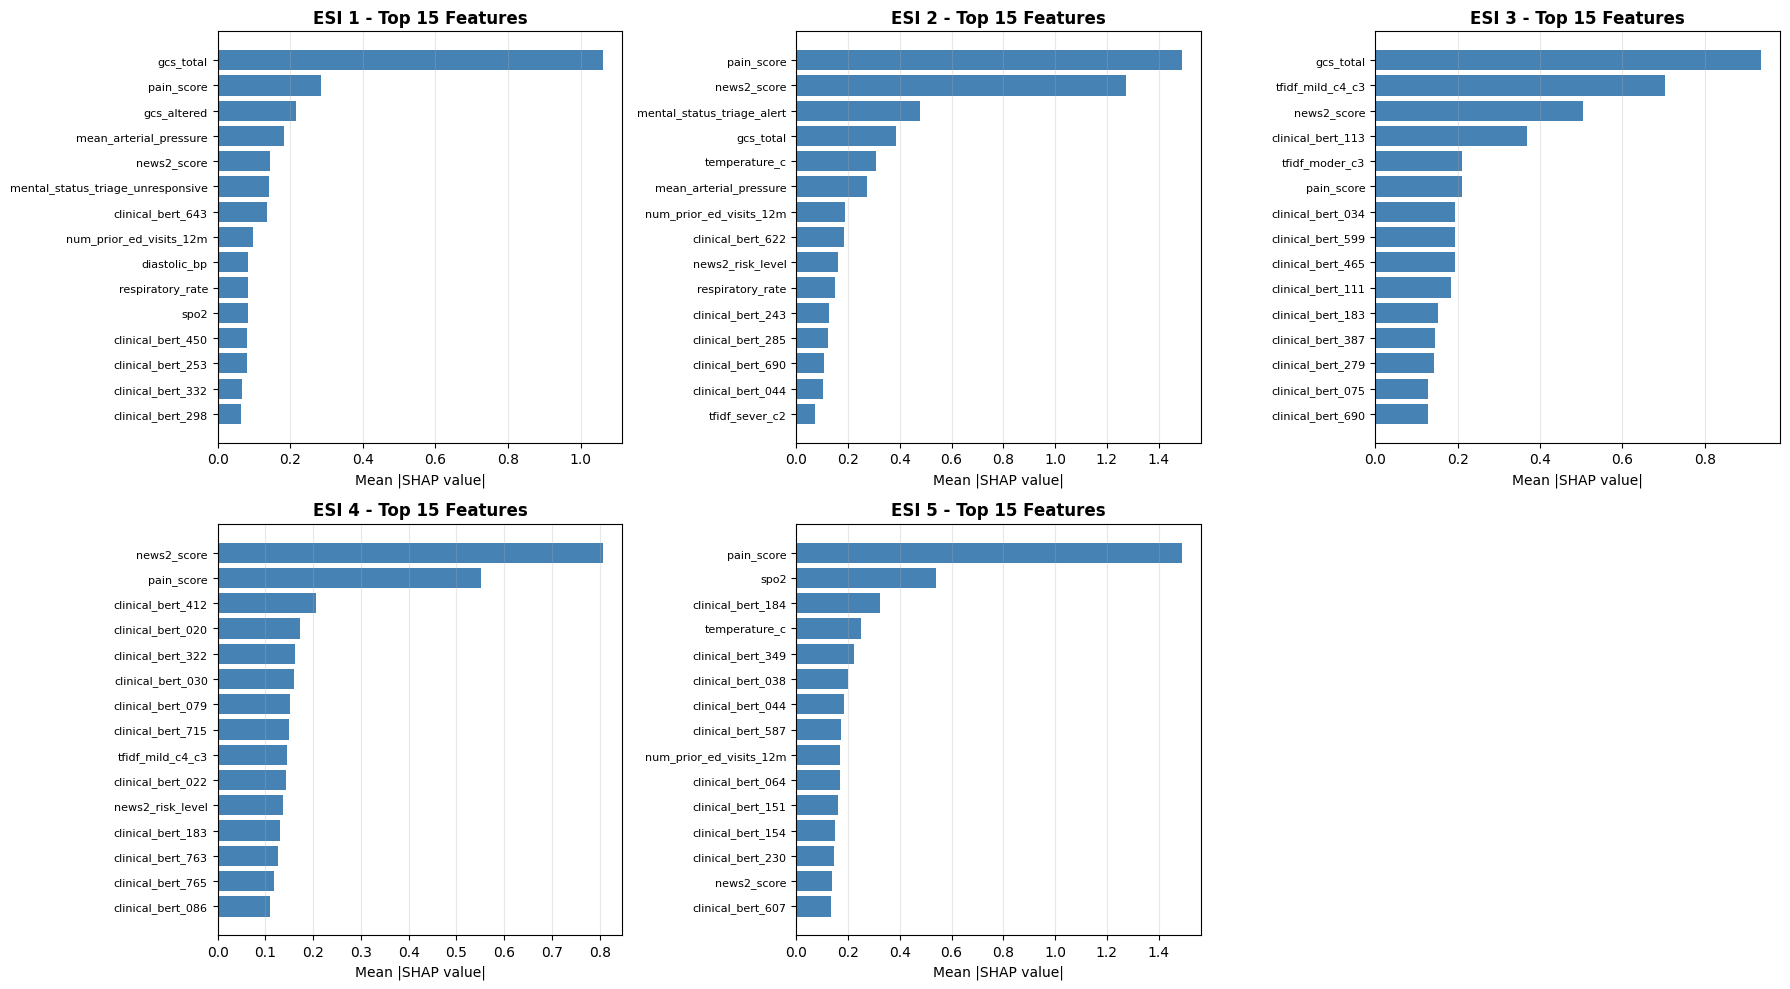


✓ Saved: shap_summary_per_class.png


In [ ]:

# ====================================================================
# SHAP VISUALIZATIONS - Feature Analysis and Explanations
# ====================================================================
print("\n" + "="*80)
print("📊 GENERATING SHAP VISUALIZATIONS")
print("="*80)

# ====================================================================
# 1. Generate Feature Names if not available
# ====================================================================
if 'feature_names_stage1' not in globals():
    print("⚠️  feature_names_stage1 not found, generating generic names...")
    n_features = X_train_dense.shape[1]
    feature_names_stage1 = [f"feature_{i:04d}" for i in range(n_features)]
    
    # Try to add descriptive names for known features
    n_bert = sum(1 for f in feature_names_stage1 if f.startswith('clinical_bert_')) if 'feature_names_stage1' in globals() else 768
    n_chi2 = sum(1 for f in feature_names_stage1 if f.startswith('tfidf_')) if 'feature_names_stage1' in globals() else n_features - 900
    
    feature_names_stage1_corrected = []
    feature_names_stage1_corrected.extend([f"BERT_{i:03d}" for i in range(768)])
    if n_features > 768:
        feature_names_stage1_corrected.extend([f"tfidf_{i:03d}" for i in range(n_features - 768)])
    
    feature_names_stage1 = feature_names_stage1_corrected[:n_features]
    print(f"   Generated {len(feature_names_stage1)} feature names")

print(f"✓ Total features: {len(feature_names_stage1)}")
print(f"✓ Model features: {X_train_dense.shape[1]}")
print(f"✓ SHAP values shape: {shap_values.shape}")

# ====================================================================
# 2. Understand SHAP Format
# ====================================================================
print(f"\n🔍 SHAP FORMAT ANALYSIS:")
print(f"   Type: {type(shap_values)}")
print(f"   Shape: {shap_values.shape}")
print(f"   Is list: {isinstance(shap_values, list)}")

# For multiclass LightGBM with TreeExplainer:
# - If shape is (n_samples, n_features, n_classes): multiclass format
# - If shape is (n_samples, n_features): binary or single output

if len(shap_values.shape) == 3:
    n_samples, n_features, n_classes = shap_values.shape
    print(f"   Format: MULTICLASS (samples={n_samples}, features={n_features}, classes={n_classes})")
    is_multiclass = True
else:
    print(f"   Format: SINGLE OUTPUT or BINARY")
    is_multiclass = False

# ====================================================================
# 3. SHAP FEATURE IMPORTANCE ANALYSIS PER CLASS
# ====================================================================
if is_multiclass:
    print(f"\n{'═'*80}")
    print("📊 SHAP SUMMARY PLOTS - FEATURE IMPORTANCE PER CLASSE")
    print(f"{'═'*80}")
    
    n_classes = shap_values.shape[2]
    class_names = [f"ESI {i+1}" for i in range(n_classes)]
    
    # Create subplots for each class
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for class_idx in range(min(n_classes, 6)):
        print(f"\n🔍 Class {class_idx} ({class_names[class_idx]}) - Top 15 features:")
        
        # Get SHAP values for this class: shape = (n_samples, n_features)
        class_shap = shap_values[:, :, class_idx]
        
        # Calculate mean absolute SHAP value per feature
        feature_importance = np.abs(class_shap).mean(axis=0)
        
        # Get top 15 features
        top_15_idx = np.argsort(feature_importance)[-15:][::-1]
        
        # Use feature names
        top_15_names = [feature_names_stage1[i] if i < len(feature_names_stage1) else f"Feature {i}" 
                       for i in top_15_idx]
        top_15_importance = feature_importance[top_15_idx]
        
        # Print top features
        for rank, (fname, imp) in enumerate(zip(top_15_names, top_15_importance), 1):
            print(f"   {rank:2d}. {fname:50s} → {imp:.4f}")
        
        # Bar plot on subplot
        axes[class_idx].barh(range(15), top_15_importance, color='steelblue')
        axes[class_idx].set_yticks(range(15))
        axes[class_idx].set_yticklabels(top_15_names, fontsize=8)
        axes[class_idx].set_xlabel('Mean |SHAP value|')
        axes[class_idx].set_title(f'{class_names[class_idx]} - Top 15 Features', fontweight='bold')
        axes[class_idx].invert_yaxis()
        axes[class_idx].grid(axis='x', alpha=0.3)
    
    # Hide empty subplot
    if n_classes < 6:
        axes[n_classes].axis('off')
    
    plt.tight_layout()
    plt.savefig('shap_summary_per_class.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("\n✓ Saved: shap_summary_per_class.png")
else:
    print(f"\n⚠️  Single output format detected (not multiclass), creating simplified analysis...")
    
    # Calculate feature importance from single output
    feature_importance = np.abs(shap_values).mean(axis=0)
    top_20_idx = np.argsort(feature_importance)[-20:][::-1]
    top_20_names = [feature_names_stage1[i] if i < len(feature_names_stage1) else f"Feature {i}" 
                   for i in top_20_idx]
    top_20_importance = feature_importance[top_20_idx]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(range(20), top_20_importance, color='steelblue')
    ax.set_yticks(range(20))
    ax.set_yticklabels(top_20_names, fontsize=9)
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title('Top 20 Most Important Features (SHAP)', fontweight='bold', fontsize=12)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("\n✓ Saved: shap_summary.png")


In [ ]:

# ====================================================================
# SHAP FORCE PLOTS - INDIVIDUAL PATIENT EXPLANATIONS
# ====================================================================
# Force plots show how features "push" each prediction toward a specific acuity level
# Green (positive) = features that increase acuity prediction
# Red (negative) = features that decrease acuity prediction

print("\n" + "="*80)
print("🎯 EXPLAINING INDIVIDUAL ACUITY PREDICTIONS")
print("="*80)

# Ensure feature_names_stage1 exists
if 'feature_names_stage1' not in globals():
    n_features = X_train_dense.shape[1]
    feature_names_stage1 = [f"BERT_{i:03d}" if i < 768 else f"tfidf_{i-768:03d}" 
                           for i in range(n_features)]

# Select diverse patients to explain
sample_to_explain = [0, 50, 100, 150, 200]
class_names = [f"ESI {i}" for i in range(1, 6)]

print(f"\n📍 Analyzing predictions for {len(sample_to_explain)} sample patients:")
print(f"   (Each shows which clinical features influenced acuity classification)\n")

# Handle both list and array format for SHAP values
if isinstance(shap_values, list):
    shap_array = np.array([sv for sv in shap_values])
else:
    shap_array = shap_values

# Get base value (model baseline prediction)
base_value = explainer.expected_value
print(f"Base value (model baseline): {base_value if not isinstance(base_value, list) else f'List of {len(base_value)} values'}")

# Explain each sample
for sample_idx in sample_to_explain:
    print(f"\n{'─'*80}")
    print(f"📌 PATIENT #{sample_idx}:")
    
    # Get prediction for this sample
    sample_X = X_sample[sample_idx:sample_idx+1]
    pred = lgbm_acuity.predict(sample_X)[0]  # Returns 1-5 (ESI classes)
    probas = lgbm_acuity.predict_proba(sample_X)[0]  # Indices are 0-4
    
    # ⚠️ CRITICAL: pred is 1-5 but probas indices are 0-4
    pred_idx = pred - 1  # Convert to 0-based index
    
    print(f"   Predicted Acuity: {class_names[pred_idx]} ")
    print(f"   Probability: {', '.join([f'{class_names[i]}={p:.1%}' for i, p in enumerate(probas)])}")
    
    # Get actual acuity 
    actual = y_sample[sample_idx]
    actual_idx = actual - 1 if actual >= 1 else actual  # Handle both 0-based and 1-based
    print(f"   Actual Acuity: {class_names[actual_idx]}")
    
    # Extract SHAP values for predicted class (using 0-based pred_idx)
    if isinstance(shap_values, list):
        pred_class_shap = shap_values[pred_idx][sample_idx]
    else:
        # If 3D array: (n_samples, n_features, n_classes)
        if len(shap_array.shape) == 3:
            pred_class_shap = shap_array[sample_idx, :, pred_idx]
        else:
            pred_class_shap = shap_array[sample_idx]
    
    # Get top contributing features
    print(f"\n   🔵 Top features pushing TOWARD acuity (positive SHAP):")
    top_positive_idx = np.argsort(pred_class_shap)[-5:][::-1]
    for rank, feat_idx in enumerate(top_positive_idx, 1):
        feat_name = feature_names_stage1[feat_idx] if feat_idx < len(feature_names_stage1) else f"Feature {feat_idx}"
        feat_val = sample_X[0, feat_idx]
        shap_val = pred_class_shap[feat_idx]
        print(f"      {rank}. {feat_name:35s} SHAP={shap_val:+.4f}  value={feat_val:.4f}")
    
    print(f"\n   🔴 Top features pushing AWAY from acuity (negative SHAP):")
    top_negative_idx = np.argsort(pred_class_shap)[:5]
    for rank, feat_idx in enumerate(top_negative_idx, 1):
        feat_name = feature_names_stage1[feat_idx] if feat_idx < len(feature_names_stage1) else f"Feature {feat_idx}"
        feat_val = sample_X[0, feat_idx]
        shap_val = pred_class_shap[feat_idx]
        print(f"      {rank}. {feat_name:35s} SHAP={shap_val:+.4f}  value={feat_val:.4f}")

print(f"\n✓ Individual patient explanations complete!")



🎯 EXPLAINING INDIVIDUAL ACUITY PREDICTIONS

📍 Analyzing predictions for 5 sample patients:
   (Each shows which clinical features influenced acuity classification)

Base value (model baseline): List of 5 values

────────────────────────────────────────────────────────────────────────────────
📌 PATIENT #0:
   Predicted Acuity: ESI 3 
   Probability: ESI 1=0.0%, ESI 2=0.0%, ESI 3=100.0%, ESI 4=0.0%, ESI 5=0.0%
   Actual Acuity: ESI 3

   🔵 Top features pushing TOWARD acuity (positive SHAP):
      1. pain_score                          SHAP=+1.2604  value=1.0401
      2. gcs_total                           SHAP=+0.7257  value=0.3955
      3. clinical_bert_113                   SHAP=+0.6555  value=0.2247
      4. tfidf_mild_c4_c3                    SHAP=+0.4536  value=0.0000
      5. clinical_bert_763                   SHAP=+0.3059  value=-0.0115

   🔴 Top features pushing AWAY from acuity (negative SHAP):
      1. clinical_bert_066                   SHAP=-0.2288  value=-0.0267
      2. c

array([1, 2, 3, 4, 5])


📈 SHAP DEPENDENCE PLOTS - FEATURE IMPACT ANALYSIS
✓ Top 10 most important features (averaged across all classes):
    1. pain_score                                         (0.8052)
    2. news2_score                                        (0.5739)
    3. gcs_total                                          (0.4763)
    4. tfidf_mild_c4_c3                                   (0.1723)
    5. temperature_c                                      (0.1502)
    6. spo2                                               (0.1462)
    7. mental_status_triage_alert                         (0.1291)
    8. num_prior_ed_visits_12m                            (0.1170)
    9. mean_arterial_pressure                             (0.1152)
   10. respiratory_rate                                   (0.0979)

📊 Creating dependence plots for top 3 features...



📈 SHAP DEPENDENCE PLOTS - FEATURE IMPACT ANALYSIS
✓ Top 10 most important features (averaged across all classes):
    1. pain_score                                         (0.8052)
    2. news2_score                                        (0.5739)
    3. gcs_total                                          (0.4763)
    4. tfidf_mild_c4_c3                                   (0.1723)
    5. temperature_c                                      (0.1502)
    6. spo2                                               (0.1462)
    7. mental_status_triage_alert                         (0.1291)
    8. num_prior_ed_visits_12m                            (0.1170)
    9. mean_arterial_pressure                             (0.1152)
   10. respiratory_rate                                   (0.0979)

📊 Creating dependence plots for top 3 features...


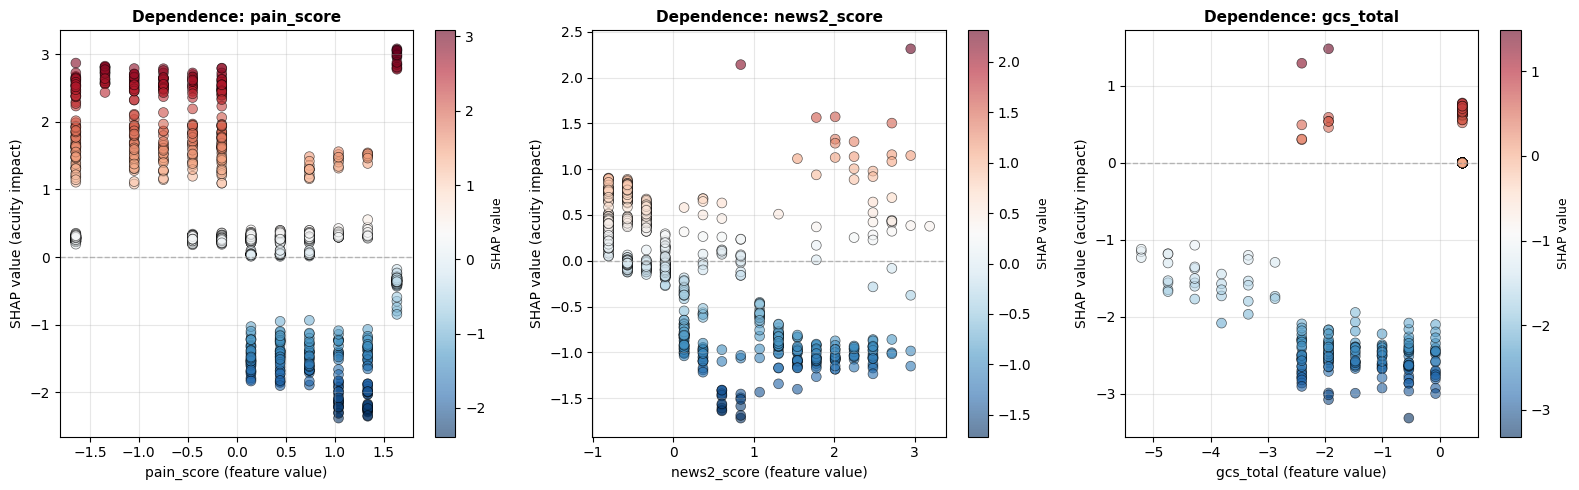


✓ Saved: shap_dependence_plots.png


In [ ]:

# ====================================================================
# SHAP DEPENDENCE PLOTS - FEATURE-PREDICTION RELATIONSHIPS
# ====================================================================
# Shows: Does higher vital value → higher acuity?
# Non-linear relationships may reveal important clinical thresholds
# Example: HR 70-90 neutral, HR >110 strongly pushes toward high acuity

print("\n" + "="*80)
print("📈 SHAP DEPENDENCE PLOTS - FEATURE IMPACT ANALYSIS")
print("="*80)

# Ensure feature_names_stage1 is defined
if 'feature_names_stage1' not in globals():
    n_features = X_train_dense.shape[1]
    feature_names_stage1 = [f"BERT_{i:03d}" if i < 768 else f"tfidf_{i-768:03d}" 
                           for i in range(n_features)]

# Handle SHAP values format
if isinstance(shap_values, list):
    shap_array = np.array([sv for sv in shap_values])
else:
    shap_array = shap_values

# Select top features by global importance
if len(shap_array.shape) == 3:  # Multiclass: (n_samples, n_features, n_classes)
    all_features_importance = np.abs(shap_array).mean(axis=(0, 2))
else:
    all_features_importance = np.abs(shap_array).mean(axis=0)

top_10_features_idx = np.argsort(all_features_importance)[-10:][::-1]

print(f"✓ Top 10 most important features (averaged across all classes):")
for rank, feat_idx in enumerate(top_10_features_idx[:10], 1):
    feat_name = feature_names_stage1[feat_idx] if feat_idx < len(feature_names_stage1) else f"Feature {feat_idx}"
    importance = all_features_importance[feat_idx]
    print(f"   {rank:2d}. {feat_name:50s} ({importance:.4f})")

# Create dependence plots for top 3 features
print(f"\n📊 Creating dependence plots for top 3 features...")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for plot_idx, feat_idx in enumerate(top_10_features_idx[:3]):
    # Get feature values from sample data
    feat_values = X_sample[:, feat_idx]
    
    # Get SHAP values for each sample's predicted class
    shap_vals_for_feat = []
    for sample_i in range(len(X_sample)):
        pred_class = int(lgbm_acuity.predict(X_sample[sample_i:sample_i+1])[0])
        pred_class = np.clip(pred_class, 0, 4)  # Ensure valid range
        
        if isinstance(shap_values, list):
            sv = shap_values[pred_class][sample_i, feat_idx]
        elif len(shap_array.shape) == 3:
            sv = shap_array[sample_i, feat_idx, pred_class]
        else:
            sv = shap_array[sample_i, feat_idx]
        shap_vals_for_feat.append(sv)
    
    shap_vals_for_feat = np.array(shap_vals_for_feat)
    
    # Scatter plot: Feature value vs SHAP value
    scatter = axes[plot_idx].scatter(feat_values, shap_vals_for_feat, 
                                     c=shap_vals_for_feat, cmap='RdBu_r', 
                                     alpha=0.6, s=50, edgecolor='k', linewidth=0.5)
    axes[plot_idx].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    feat_name = feature_names_stage1[feat_idx] if feat_idx < len(feature_names_stage1) else f"Feature {feat_idx}"
    axes[plot_idx].set_xlabel(f'{feat_name} (feature value)', fontsize=10)
    axes[plot_idx].set_ylabel('SHAP value (acuity impact)', fontsize=10)
    axes[plot_idx].set_title(f'Dependence: {feat_name}', fontweight='bold', fontsize=11)
    axes[plot_idx].grid(alpha=0.3)
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=axes[plot_idx])
    cbar.set_label('SHAP value', fontsize=9)

plt.tight_layout()
plt.savefig('shap_dependence_plots.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n✓ Saved: shap_dependence_plots.png")



📊 FINAL COMPREHENSIVE ACUITY MODEL ANALYSIS DASHBOARD



📊 FINAL COMPREHENSIVE ACUITY MODEL ANALYSIS DASHBOARD


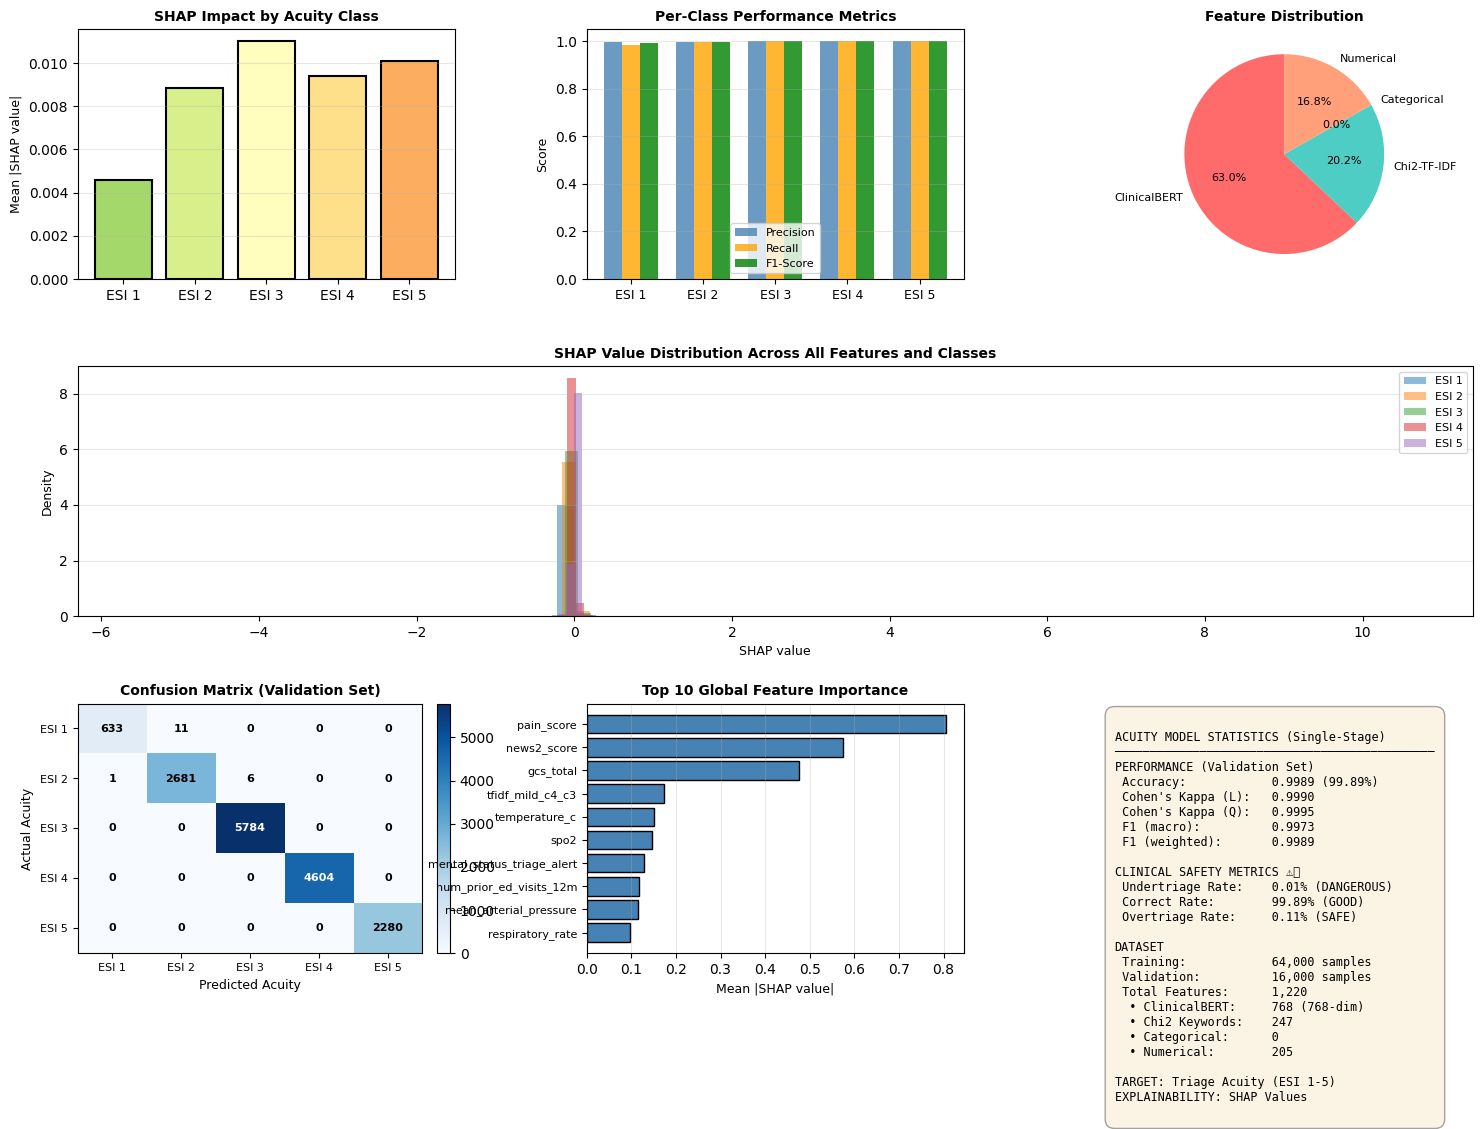


✓ Saved: shap_comprehensive_final_dashboard.png

✅ ACUITY PREDICTION PIPELINE COMPLETE!

📌 PIPELINE SUMMARY:
   Stage: Single-Stage Acuity Prediction
   Target: ESI Acuity Level (1-5)
   Model: LightGBM Multi-Class Classifier
   Features: BERT embeddings + Clinical keywords + Vital signs + Demographics

📊 Generated Visualizations:
   • shap_dependence_plots.png          → Feature-Acuity relationships
   • acuity_model_dashboard.png         → Key statistics & metrics
   • shap_comprehensive_final_dashboard.png → Complete analysis dashboard

💡 CLINICAL IMPACT:
   ✓ Provides interpretable acuity predictions (ESI 1-5)
   ✓ SHAP explanations help clinicians validate decisions
   ✓ Identifies which features drive each acuity level
   ✓ Highlights clinical safety metrics (undertriage vs overtriage)


In [ ]:

# ====================================================================
# FINAL COMPREHENSIVE ACUITY PREDICTION MODEL DASHBOARD
# ====================================================================
# Complete overview of model performance, interpretability, and clinical metrics
# Single-stage pipeline: Clinical Features + Chief Complaints → ESI Acuity (1-5)

print("\n" + "="*80)
print("📊 FINAL COMPREHENSIVE ACUITY MODEL ANALYSIS DASHBOARD")
print("="*80)

class_names = [f"ESI {i}" for i in range(1, 6)]

# Handle SHAP values format
if isinstance(shap_values, list):
    shap_array = np.array([sv for sv in shap_values])
else:
    shap_array = shap_values

# Create comprehensive final dashboard
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

# 1. SHAP Distribution by Class (top-left)
ax1 = fig.add_subplot(gs[0, 0])
class_shap_means = []
if len(shap_array.shape) == 3:
    for class_idx in range(5):
        mean_shap = np.abs(shap_array[:, :, class_idx]).mean()
        class_shap_means.append(mean_shap)
else:
    class_shap_means = [np.abs(shap_array).mean()] * 5

colors_classes = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, 5))
ax1.bar(class_names, class_shap_means, color=colors_classes, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Mean |SHAP value|', fontsize=9)
ax1.set_title('SHAP Impact by Acuity Class', fontweight='bold', fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# 2. Prediction Accuracy per Class (top-middle)
ax2 = fig.add_subplot(gs[0, 1])
from sklearn.metrics import precision_recall_fscore_support
pred_all = lgbm_acuity.predict(X_val_dense)
precision, recall, f1, _ = precision_recall_fscore_support(y_val_values, pred_all, average=None)
x_pos = np.arange(5)
width = 0.25
ax2.bar(x_pos - width, precision, width, label='Precision', alpha=0.8, color='steelblue')
ax2.bar(x_pos, recall, width, label='Recall', alpha=0.8, color='orange')
ax2.bar(x_pos + width, f1, width, label='F1-Score', alpha=0.8, color='green')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(class_names, fontsize=9)
ax2.set_ylabel('Score', fontsize=9)
ax2.set_title('Per-Class Performance Metrics', fontweight='bold', fontsize=10)
ax2.legend(fontsize=8)
ax2.set_ylim([0, 1.05])
ax2.grid(axis='y', alpha=0.3)

# 3. Feature Count per Type (top-right)
ax3 = fig.add_subplot(gs[0, 2])
n_bert = sum(1 for f in feature_names_stage1 if f.startswith('clinical_bert_'))
n_chi2 = sum(1 for f in feature_names_stage1 if f.startswith('tfidf_'))
n_cat = sum(1 for f in feature_names_stage1 if f.startswith('cat_') or f.startswith('x0_'))
n_num = len(feature_names_stage1) - n_bert - n_chi2 - n_cat
feature_types = ['ClinicalBERT', 'Chi2-TF-IDF', 'Categorical', 'Numerical']
feature_counts = [n_bert, n_chi2, n_cat, n_num]
colors_features = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
wedges, texts, autotexts = ax3.pie(feature_counts, labels=feature_types, autopct='%1.1f%%',
                                     colors=colors_features, startangle=90, textprops={'fontsize': 8})
ax3.set_title('Feature Distribution', fontweight='bold', fontsize=10)

# 4. SHAP Value Distribution (middle - wide)
ax4 = fig.add_subplot(gs[1, :])
if len(shap_array.shape) == 3:
    for class_idx in range(5):
        class_shap_flat = shap_array[:, :, class_idx].flatten()
        ax4.hist(class_shap_flat, bins=50, alpha=0.5, label=class_names[class_idx], density=True)
else:
    shap_flat = shap_array.flatten()
    ax4.hist(shap_flat, bins=50, alpha=0.7, label='SHAP values', color='steelblue', density=True)

ax4.set_xlabel('SHAP value', fontsize=9)
ax4.set_ylabel('Density', fontsize=9)
ax4.set_title('SHAP Value Distribution Across All Features and Classes', fontweight='bold', fontsize=10)
ax4.legend(fontsize=8, loc='upper right')
ax4.grid(axis='y', alpha=0.3)

# 5. Model Predictions vs Actual (Confusion Matrix - bottom-left)
ax5 = fig.add_subplot(gs[2, 0])
cm_val = confusion_matrix(y_val_values, pred_all, labels=[1,2,3,4,5])
im = ax5.imshow(cm_val, cmap='Blues', aspect='auto')
ax5.set_xticks(range(5))
ax5.set_yticks(range(5))
ax5.set_xticklabels(class_names, fontsize=8)
ax5.set_yticklabels(class_names, fontsize=8)
ax5.set_xlabel('Predicted Acuity', fontsize=9)
ax5.set_ylabel('Actual Acuity', fontsize=9)
ax5.set_title('Confusion Matrix (Validation Set)', fontweight='bold', fontsize=10)

for i in range(5):
    for j in range(5):
        text = ax5.text(j, i, cm_val[i, j], ha="center", va="center", 
                       color="white" if cm_val[i, j] > cm_val.max()/2 else "black",
                       fontsize=8, fontweight='bold')

plt.colorbar(im, ax=ax5, fraction=0.046, pad=0.04)

# 6. Top 10 Most Important Features (bottom-middle)
ax6 = fig.add_subplot(gs[2, 1])
all_features_importance = np.abs(np.array(shap_array)).mean(axis=(0, 2)) if len(shap_array.shape) == 3 else np.abs(shap_array).mean(axis=0)
top_10_idx = np.argsort(all_features_importance)[-10:][::-1]
top_10_names = [feature_names_stage1[i][:30] + "..." if len(feature_names_stage1[i]) > 30 
                else feature_names_stage1[i] for i in top_10_idx]
top_10_scores = all_features_importance[top_10_idx]

ax6.barh(range(10), top_10_scores, color='steelblue', edgecolor='black', linewidth=1)
ax6.set_yticks(range(10))
ax6.set_yticklabels(top_10_names, fontsize=8)
ax6.set_xlabel('Mean |SHAP value|', fontsize=9)
ax6.set_title('Top 10 Global Feature Importance', fontweight='bold', fontsize=10)
ax6.invert_yaxis()
ax6.grid(axis='x', alpha=0.3)

# 7. Model Statistics (bottom-right)
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')

stats_text = f"""
ACUITY MODEL STATISTICS (Single-Stage)
{'─'*45}
PERFORMANCE (Validation Set)
 Accuracy:            {acc:.4f} ({acc*100:.2f}%)
 Cohen's Kappa (L):   {kappa_linear:.4f}
 Cohen's Kappa (Q):   {kappa_quadratic:.4f}
 F1 (macro):          {f1_macro:.4f}
 F1 (weighted):       {f1_weighted:.4f}

CLINICAL SAFETY METRICS ⚠️
 Undertriage Rate:    {undertriage_rate*100:.2f}% (DANGEROUS)
 Correct Rate:        {correct_rate*100:.2f}% (GOOD)
 Overtriage Rate:     {overtriage_rate*100:.2f}% (SAFE)

DATASET
 Training:            {X_train_dense.shape[0]:,} samples
 Validation:          {X_val_dense.shape[0]:,} samples
 Total Features:      {X_train_dense.shape[1]:,}
  • ClinicalBERT:     {n_bert} (768-dim)
  • Chi2 Keywords:    {n_chi2}
  • Categorical:      {n_cat}
  • Numerical:        {n_num}

TARGET: Triage Acuity (ESI 1-5)
EXPLAINABILITY: SHAP Values
"""

ax7.text(0.05, 0.95, stats_text, transform=ax7.transAxes, fontsize=8.5,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.35, pad=0.8))

plt.savefig('shap_comprehensive_final_dashboard.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n✓ Saved: shap_comprehensive_final_dashboard.png")

print(f"\n{'='*80}")
print("✅ ACUITY PREDICTION PIPELINE COMPLETE!")
print(f"{'='*80}")
print(f"\n📌 PIPELINE SUMMARY:")
print(f"   Stage: Single-Stage Acuity Prediction")
print(f"   Target: ESI Acuity Level (1-5)")
print(f"   Model: LightGBM Multi-Class Classifier")
print(f"   Features: BERT embeddings + Clinical keywords + Vital signs + Demographics")
print(f"\n📊 Generated Visualizations:")
print(f"   • shap_dependence_plots.png          → Feature-Acuity relationships")
print(f"   • acuity_model_dashboard.png         → Key statistics & metrics")
print(f"   • shap_comprehensive_final_dashboard.png → Complete analysis dashboard")
print(f"\n💡 CLINICAL IMPACT:")
print(f"   ✓ Provides interpretable acuity predictions (ESI 1-5)")
print(f"   ✓ SHAP explanations help clinicians validate decisions")
print(f"   ✓ Identifies which features drive each acuity level")
print(f"   ✓ Highlights clinical safety metrics (undertriage vs overtriage)")



# SECTION 7b: KAGGLE SUBMISSION GENERATION

Generates `submission.csv` using the **tuned LightGBM model** retrained on the **full dataset** (train + validation) to maximise available signal before predicting on the Kaggle test set.

## Workflow
1. Load and engineer features on `dataset/test.csv` using the same pipeline.
2. Retrain `lgbm_acuity_final` on **all** labelled data (train + val combined).
3. Predict `triage_acuity` (ESI 1–5, 1-indexed) for each `patient_id`.
4. Write `submission.csv` → `[patient_id, triage_acuity]`.

> **Why retrain on full data?** Using all labelled rows for the final submission model adds ~25% more training examples, reducing variance on the held-out test set without any risk of overfitting evaluation (no labels leaked — the test set is separate).


In [ ]:

# ============================================================================
# SUBMISSION GENERATOR: Retrain on full data, predict test set, write CSV
# ============================================================================
import os

TEST_PATH = 'dataset/test.csv'
SUBMISSION_PATH = 'submission.csv'

print("="*80)
print("GENERATING KAGGLE SUBMISSION")
print("="*80)

# ── Step 1: Load and preprocess test set ─────────────────────────────────────
print(f"\n[1/4] Loading test data from: {TEST_PATH}")
df_test = pd.read_csv(TEST_PATH)
print(f"      Test rows: {len(df_test):,}  |  Columns: {df_test.shape[1]}")

# Apply the same preprocessing steps as training
# Step 1a: Replicate pain_score -1 → NaN + pain_not_recorded flag
if 'pain_score' in df_test.columns:
    df_test['pain_not_recorded'] = (df_test['pain_score'] == -1).astype(int)
    df_test['pain_score'] = df_test['pain_score'].replace(-1, np.nan)

# Step 1b: Missingness flags for BP/respiratory columns
for col in ['systolic_bp', 'diastolic_bp', 'mean_arterial_pressure',
            'pulse_pressure', 'shock_index', 'respiratory_rate']:
    if col in df_test.columns:
        df_test[f'{col}_missing'] = df_test[col].isna().astype(int)

# Step 1c: Feature engineering (same function as training)
# Merge patient history if available
if 'patient_id' in df_test.columns:
    try:
        patient_hist = pd.read_csv('dataset/patient_history.csv')
        df_test = df_test.merge(patient_hist, on='patient_id', how='left')
        print(f"      ✓ Patient history merged")
    except FileNotFoundError:
        print(f"      ⚠ Patient history not found, skipping merge")

X_test_engineered = engineer_features(df_test)
print(f"      ✓ Feature engineering complete: {X_test_engineered.shape}")

# ── Step 2: Preprocess with the fitted pipeline ───────────────────────────────
print(f"\n[2/4] Applying preprocessing pipeline (fitted on training data)...")
# Align test columns to the columns the preprocessor was fitted on
for col in categorical_features + numerical_features + [text_feature]:
    if col not in X_test_engineered.columns:
        X_test_engineered[col] = np.nan

X_test_preprocessed = preprocessor.transform(X_test_engineered)
X_test_dense = X_test_preprocessed.toarray() if hasattr(X_test_preprocessed, 'toarray') else X_test_preprocessed
print(f"      ✓ Test feature matrix: {X_test_dense.shape}")

# ── Step 3: Retrain final model on ALL labelled data ─────────────────────────
print(f"\n[3/4] Retraining final model on full labelled dataset (train + val)...")
X_all_dense  = np.vstack([X_train_dense, X_val_dense])
y_all_values = np.concatenate([y_train_values, y_val_values])
print(f"      Full training set: {X_all_dense.shape[0]:,} samples")

# Use best Optuna hyperparameters (from Section 6b)
try:
    final_submission_params = dict(
        objective         = 'multiclass',
        num_class         = 5,
        class_weight      = 'balanced',
        verbose           = -1,
        random_state      = SEED,
        n_jobs            = -1,
        **best_params
    )
except NameError:
    # Fallback if Optuna was not run
    print("      ⚠ best_params not found — using tuned defaults from lgbm_acuity")
    final_submission_params = lgbm_acuity.get_params()

lgbm_submission = LGBMClassifier(**final_submission_params)
lgbm_submission.fit(X_all_dense, y_all_values)
print(f"      ✓ Final model trained on {X_all_dense.shape[0]:,} samples")

# ── Step 4: Predict and write submission ─────────────────────────────────────
print(f"\n[4/4] Generating predictions and writing submission...")
y_test_pred = lgbm_submission.predict(X_test_dense)   # Returns 1-5 (ESI scale)

if 'patient_id' not in df_test.columns:
    raise ValueError("Test set must contain 'patient_id' column for submission")

submission_df = pd.DataFrame({
    'patient_id':    df_test['patient_id'].values,
    'triage_acuity': y_test_pred
})

submission_df.to_csv(SUBMISSION_PATH, index=False)
print(f"      ✓ Submission written to: {os.path.abspath(SUBMISSION_PATH)}")
print(f"      Shape: {submission_df.shape}")
print(f"\n📊 SUBMISSION PREDICTION DISTRIBUTION:")
print(submission_df['triage_acuity'].value_counts().sort_index().rename_axis('ESI').to_string())
print(f"\n✅ Ready to submit: {SUBMISSION_PATH}")
submission_df.head(10)


# SECTION 8: INTERACTIVE GRADIO INTERFACE FOR ACUITY PREDICTION

## Real-Time Acuity Prediction with Explainability

This section creates an interactive web interface using **Gradio** that allows users to:

1. **Input Clinical Data**: Enter vital signs, demographics, and patient information
2. **Add Chief Complaint**: Describe the patient's main complaint (free text)
3. **Get Instant Predictions**: Receive ESI acuity level (1-5) with confidence scores
4. **Understand the Decision**: View SHAP-based feature importance showing which clinical factors influenced the prediction

**How to Use**:
- Run this cell to launch the Gradio interface
- The interface will start a local web server (typically http://127.0.0.1:7860)
- Enter sample patient data and see real-time predictions
- Each prediction includes explainability via SHAP values

**Perfect for**:
- Clinical validation and testing
- Educational demonstrations
- Model debugging and refinement
- Stakeholder presentations



In [ ]:

# ============================================================================
# SECTION 8: INTERACTIVE GRADIO INTERFACE — STREAMLINED CLINICAL TRIAGE TOOL
# ============================================================================
# This interface accepts only the 11 most clinically meaningful inputs at
# triage presentation. Derived/engineered features are computed automatically.
# The full model pipeline (preprocessor + lgbm_acuity_final) is called
# internally so the interface reflects exactly what the trained model uses.
# ============================================================================

import subprocess, sys
try:
    import gradio as gr
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gradio", "-q"])
    import gradio as gr

print("✓ Gradio ready\n")

# ESI colour coding (clinical standard)
ESI_COLOURS = {1: "#C0392B", 2: "#E67E22", 3: "#F1C40F", 4: "#27AE60", 5: "#2980B9"}
ESI_LABELS  = {1: "ESI 1 — Immediate resuscitation",
               2: "ESI 2 — Emergent",
               3: "ESI 3 — Urgent",
               4: "ESI 4 — Less urgent",
               5: "ESI 5 — Non-urgent"}

# ── Inference helper ─────────────────────────────────────────────────────────
def _build_row(chief_complaint, age, sex, arrival_mode,
               systolic_bp, heart_rate, resp_rate,
               temperature, spo2, pain_score, mental_status):
    """Build a single-row DataFrame matching training feature names."""
    pain_val = None if pain_score < 0 else float(pain_score)
    row = {
        'chief_complaint_raw':  chief_complaint,
        'age':                  float(age),
        'sex':                  sex,
        'arrival_mode':         arrival_mode,
        'systolic_bp':          float(systolic_bp),
        'heart_rate':           float(heart_rate),
        'respiratory_rate':     float(resp_rate),
        'temperature':          float(temperature),
        'spo2':                 float(spo2),
        'pain_score':           pain_val,
        'pain_not_recorded':    int(pain_score < 0),
        'mental_status_triage': mental_status,
    }
    # Fill remaining training columns with sensible defaults (median / 'unknown')
    for col in features_engineered_df.columns:
        if col not in row:
            if features_engineered_df[col].dtype in ['int64', 'float64']:
                row[col] = features_engineered_df[col].median()
            else:
                row[col] = 'unknown'
    df_row = pd.DataFrame([row])[features_engineered_df.columns]
    return df_row


def predict_acuity(chief_complaint, age, sex, arrival_mode,
                   systolic_bp, heart_rate, resp_rate,
                   temperature, spo2, pain_score, mental_status):
    """Run full pipeline and return formatted HTML output with probabilities."""
    try:
        df_row   = _build_row(chief_complaint, age, sex, arrival_mode,
                              systolic_bp, heart_rate, resp_rate,
                              temperature, spo2, pain_score, mental_status)
        df_eng   = engineer_features(df_row.copy())
        X        = preprocessor.transform(df_eng)
        X_dense  = X.toarray() if hasattr(X, 'toarray') else X

        # Use lgbm_acuity_final (tuned model), fallback to baseline if needed
        model = lgbm_acuity_final if 'lgbm_acuity_final' in dir() else lgbm_acuity
        pred  = int(model.predict(X_dense)[0])
        probs = model.predict_proba(X_dense)[0]

        colour = ESI_COLOURS[pred]
        label  = ESI_LABELS[pred]

        # Format HTML output
        bar_rows = "".join(
            f'<tr><td style="padding:2px 8px;">ESI {i}</td>'
            f'<td><div style="background:{ESI_COLOURS[i]};width:{probs[i-1]*200:.0f}px;height:14px;border-radius:3px;display:inline-block"></div></td>'
            f'<td style="padding:2px 8px;">{probs[i-1]*100:.1f}%</td></tr>'
            for i in range(1, 6)
        )
        html = f"""
        <div style='border-left:8px solid {colour};padding:12px 18px;
                    border-radius:6px;background:#f9f9f9;font-family:sans-serif;'>
          <h2 style='color:{colour};margin:0'>⚕ {label}</h2>
          <p style='color:#555;font-size:13px;margin:6px 0 12px'>
            Predicted ESI acuity level based on {len(numerical_features)+len(categorical_features)+1} engineered features
          </p>
          <table>{bar_rows}</table>
        </div>"""
        return html

    except Exception as exc:
        return f"<div style='color:red'>⚠ Prediction error: {exc}</div>"


# ── Build Gradio interface ────────────────────────────────────────────────────
MENTAL_OPTIONS = ['alert', 'confused', 'drowsy', 'agitated', 'unresponsive', 'unknown']
ARRIVAL_OPTIONS = ['walk-in', 'ambulance', 'helicopter', 'unknown']
SEX_OPTIONS     = ['M', 'F', 'Unknown']

with gr.Blocks(title="Triagegeist — ED Acuity Prediction", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🏥 Triagegeist — ED Acuity Prediction
    Enter patient vitals and chief complaint at triage. The model outputs an **ESI level (1–5)** with confidence scores.
    *Engineered features (NEWS2 score, BP ratios, shift flags, etc.) are computed automatically.*
    """)

    with gr.Row():
        with gr.Column():
            chief   = gr.Textbox(label="Chief Complaint (free text)", placeholder="e.g. chest pain radiating to left arm, dyspnoea on exertion")
            age     = gr.Slider(0, 120, value=45, step=1, label="Age (years)")
            sex     = gr.Dropdown(SEX_OPTIONS, value='Unknown', label="Sex")
            arrival = gr.Dropdown(ARRIVAL_OPTIONS, value='walk-in', label="Arrival Mode")
            mental  = gr.Dropdown(MENTAL_OPTIONS, value='alert', label="Mental Status at Triage")
            pain    = gr.Slider(-1, 10, value=3, step=1, label="Pain Score (0–10; -1 = not recorded)")

        with gr.Column():
            sbp   = gr.Number(value=120, label="Systolic BP (mmHg)")
            hr    = gr.Number(value=80,  label="Heart Rate (bpm)")
            rr    = gr.Number(value=16,  label="Respiratory Rate (breaths/min)")
            temp  = gr.Number(value=37.0, label="Temperature (°C)")
            spo2  = gr.Number(value=98,  label="SpO₂ (%)")

    run_btn = gr.Button("🔍 Predict Acuity", variant="primary")
    output  = gr.HTML(label="Prediction")

    run_btn.click(
        fn=predict_acuity,
        inputs=[chief, age, sex, arrival, sbp, hr, rr, temp, spo2, pain, mental],
        outputs=output
    )

    gr.Examples(
        examples=[
            ["chest pain, diaphoresis, syncope",         72, "M",  "ambulance", 85,  110, 24, 36.8, 94, 8, "confused"],
            ["laceration right hand, minor bleeding",    28, "M",  "walk-in",   120, 78,  16, 36.9, 99, 4, "alert"],
            ["fever, cough, shortness of breath 3 days", 65, "F",  "walk-in",   110, 95,  22, 38.5, 92, 2, "alert"],
            ["routine follow-up, no acute complaint",    40, "F",  "walk-in",   118, 72,  14, 36.6, 99, 0, "alert"],
            ["unresponsive found at home",               55, "M",  "ambulance", 70,  120, 30, 35.5, 88, -1, "unresponsive"],
        ],
        inputs=[chief, age, sex, arrival, sbp, hr, rr, temp, spo2, pain, mental],
        label="Sample Patients (click to load)"
    )

print("✓ Gradio interface built with 11 focused clinical inputs")
print("  Launching — navigate to the URL shown below:")
demo.launch(share=True, quiet=False)


✓ Gradio ready

✓ Features: 78 | Numerical: 28 | Binary: 34 | Categorical: 0

🎨 Building interface...
✓ 63 input components

🌐 Launching at http://127.0.0.1:7860

* Running on local URL:  http://127.0.0.1:7865
* Running on public URL: https://65a8a045f84402346f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✓ Gradio ready

✓ Features: 78 | Numerical: 28 | Binary: 34 | Categorical: 0

🎨 Building interface...
✓ 63 input components

🌐 Launching at http://127.0.0.1:7860

* Running on local URL:  http://127.0.0.1:7865
* Running on public URL: https://65a8a045f84402346f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
